# Car Dataset Complete EDA - Cleaning

## 1. Dataset Analysis

In [1]:
import pandas as pd

In [2]:
car_dataset = pd.read_csv('car(in).csv')

In [3]:
car_dataset.head(10)

,Name,Price,Used For,Transmisson,Colour,Make Year,Mileage,Engine (CC),Fuel,Kilometer Run,Waranty,Types
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,"रू. 24,75,000रू. 25,00,000",Private Use,Manual2WD,Brown,2015,14,1400,Petrol,42000,NaN,NaN
1,Excellent car on sale (Hyundai),"रू. 7,50,000",NaN,Auto2WD,Light blue,2005,11,1399,Petrol,87412,NaN,NaN
2,TATA 407 Container (Tata),"रू. 7,00,000",NaN,Manual - 2WD,White,2013,NaN,2956,Diesel,60000,NaN,NaN
3,4x4 swaraj Mazda (Mahindra),"रू. 6,00,000",NaN,Manual - 4WD,NaN,2017,NaN,NaN,Diesel,NaN,NaN,NaN
4,i20 Active good for used few time (Hyundai),रू. 375,NaN,Auto - 2WD,white,2019,17,1200,Petrol,2400,NaN,NaN
5,Tata Sumo Gold 2014 GX (Tata),"रू. 14,00,000",NaN,Manual2WD,Artic Silver,2014,12,2956cc,Diesel,NaN,NaN,NaN
6,Mega XL hatti gadi (Tata),"रू. 7,00,000",NaN,Auto2WD,Brown chocolate colour,2019,15,889,Petrol,80000,NaN,NaN
7,Maruti Suzuki Alto 2004 On Sale (Maruti Suzuki),"रू. 5,80,000",NaN,Manual - 2WD,Black,2004,NaN,800,Petrol,75000,NaN,NaN
8,Grand i10 magna 2014 (Hyundai),"रू. 18,45,000",NaN,Manual2WD,Silver,2014,NaN,1200,Petrol,31000,NaN,NaN
9,Blue colour 2016 model Baleno (Maruti Suzuki),"रू. 20,50,000",private,Auto4WD,blue,2016,17/18 km,1200,Petrol,41000,chaa.,NaN


In [4]:
car_dataset.tail(10)

,Name,Price,Used For,Transmisson,Colour,Make Year,Mileage,Engine (CC),Fuel,Kilometer Run,Waranty,Types
838,Mahendra bolero pickup truck (Mahindra),"रू. 14,50,000",NaN,Manual - 4WD,gray,2017,NaN,2500,Diesel,42000,NaN,NaN
839,"Eco cargo van 2021 model ,16800 km running ,12...","रू. 12,00,000",1 year,Auto2WD,White,2021 last mdel,16-18,1200,Petrol,16800,No,NaN
840,Bolero maxitruck (Mahindra),"रू. 16,75,000",NaN,Auto - 4WD,white,2019,NaN,2500,Diesel,56000,NaN,NaN
841,2010 Model I10 Magna 1.2 New Shape On Sale (Hy...,"रू. 14,65,000",12 Years,Manual - 2WD,Silver,2010,20,1200,Petrol,60000,A,NaN
842,Honda City 2004 (Honda),"रू. 7,99,999",NaN,Manual - 2WD,Metallic Grey,2004,NaN,1498,Petrol,108000,NaN,NaN
843,Hyundai grand i10 (Hyundai),"रू. 24,50,000",2 years,Manual - 2WD,silver,2020,2025,1200,Petrol,26500,NaN,NaN
844,Well maintained car. Everything is fine. Singl...,"रू. 19,25,000",6 years,Manual2WD,Navy blue,2015,15,1200,Petrol,60000,No,NaN
845,VW Polo 2014 Highline 1200 (Renault),"रू. 19,50,000",7,Manual2WD,Carbon Steel ( Dark Grey),2014,12 to 14,1200,Petrol,60000,NaN,NaN
846,Hyundai i10 magna 2014 (Hyundai),"रू. 17,50,000",NaN,Manual - 2WD,silver,2014,NaN,1200,Petrol,93000,NaN,NaN
847,nissan xtrail 2007 model for sale or exchange ...,"रू. 24,50,000",private use,Auto - 4WD,cream,2007,13,2200,Diesel,60000,no warenty,NaN


In [5]:
car_dataset.shape

(848, 12)

In [6]:
car_dataset.isnull().sum()

Name               0
Price              0
Used For         491
Transmisson        0
Colour            82
Make Year          0
Mileage          390
Engine (CC)      107
Fuel               0
Kilometer Run    142
Waranty          639
Types            848
dtype: int64

### 1.1 Visualization: Missing Data Analysis

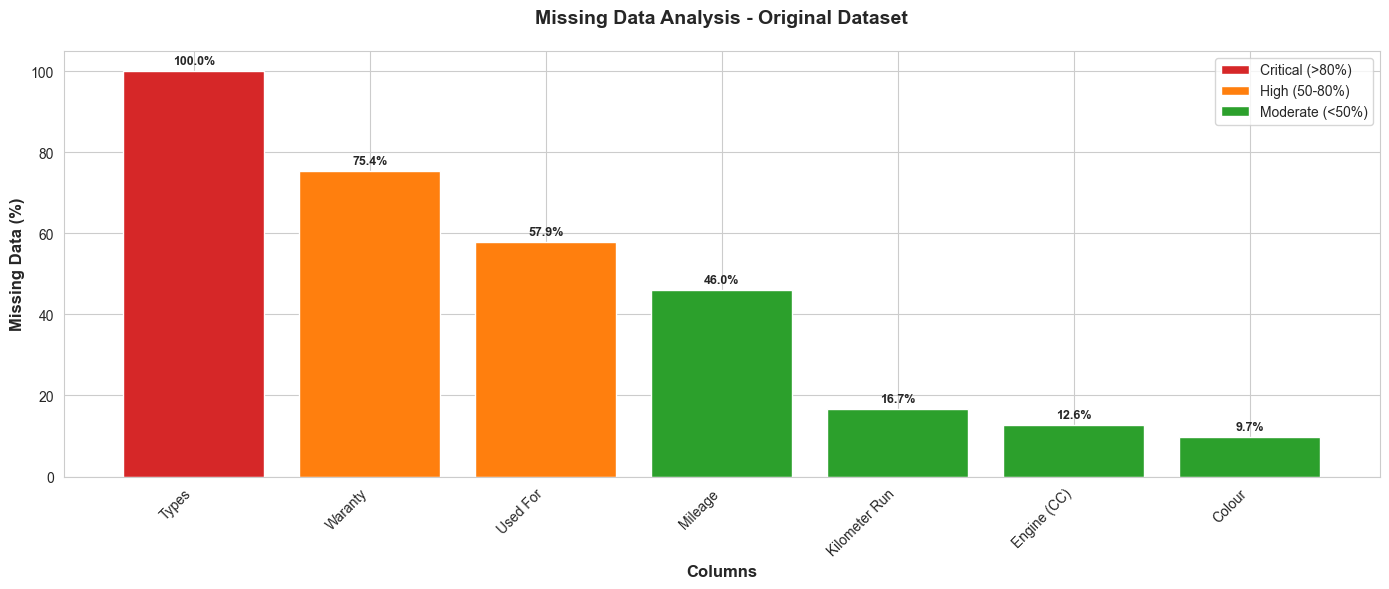


=== Missing Data Summary ===
       Column  Missing_Count  Missing_Percent
        Types            848       100.000000
      Waranty            639        75.353774
     Used For            491        57.900943
      Mileage            390        45.990566
Kilometer Run            142        16.745283
  Engine (CC)            107        12.617925
       Colour             82         9.669811


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Calculate missing data percentage
missing_data = car_dataset.isnull().sum()
missing_percent = (missing_data / len(car_dataset)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

# Filter columns with missing data
missing_df_filtered = missing_df[missing_df['Missing_Count'] > 0]

# Create bar plot
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(missing_df_filtered['Column'], missing_df_filtered['Missing_Percent'], 
               color=['#d62728' if x > 80 else '#ff7f0e' if x > 50 else '#2ca02c' for x in missing_df_filtered['Missing_Percent']])

ax.set_xlabel('Columns', fontsize=12, fontweight='bold')
ax.set_ylabel('Missing Data (%)', fontsize=12, fontweight='bold')
ax.set_title('Missing Data Analysis - Original Dataset', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 105)

# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars, missing_df_filtered['Missing_Percent'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Critical (>80%)'),
    Patch(facecolor='#ff7f0e', label='High (50-80%)'),
    Patch(facecolor='#2ca02c', label='Moderate (<50%)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('DataVisualisationAssets/Missing_Data_Analysis_Original_Dataset.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Missing Data Summary ===")
print(missing_df_filtered.to_string(index=False))

## 2. Column Specific Analysis

In [8]:
car_dataset['Waranty'].value_counts()

Waranty
No                                  60
no                                  45
no warranty                          9
Yes                                  8
No warranty                          5
                                    ..
@                                    1
upto 2025 March                      1
Engine and gearbox for two years     1
Na                                   1
A                                    1
Name: count, Length: 67, dtype: int64

In [9]:
car_dataset['Waranty'].unique()

array([nan, 'chaa.', 'no', '7 uears', 'No', '-', 'Yes', 'thank you',
       'no warranty', 'Not', 'No warannty', 'Company warranty', 'non',
       '6 month on engine /gear box /clus plate', '100000KM 3 YEARS',
       'Company', '5years company warranty', 'Visit check up', '1 years',
       '0', 'almots 8 yrs', 'accident free', '3 yeara', '4 years',
       'No warranty', 'Available upto 1yr', 'Engine', '3 months',
       'Dealer', 'No warranty.', 'as per company rules',
       '7 years battery warranty', 'nop', '1 week', '3 years', 'Buy Back',
       '8 years', '1 year', 'company warranty', 'Two months',
       'Company Warrenty', 'NO', 'As per company rules', '4years',
       'no warenty', 'Due', 'In company warranty', 'yes', '5 years',
       'इन्जिन 1 बर्ष बेटरि 6 महिना।', 'none', 'w', 'No warrant',
       'Manufacturer/Importer', 'Company..', 'No Warranty', 'No,',
       'Available', 'Some days', '3 years warranty', 'Buy back', '@', '1',
       'upto 2025 March', 'Manufacturer/ Impo

In [10]:
car_dataset['Used For'].unique()

array(['Private Use', nan, 'private', 'personal', 'like new', '1 year',
       '1', '3 years', '-', 'Private', '5 years', 'Home', 'Prasnal', '10',
       '6 years', '12 years', 'home office', '13', '16', '32 months',
       'Supply Transportation', 'School', 'few times', 'personal use',
       '5 MONTHS', 'Persona', '14 years', 'office', '6months',
       'Office purpose', '16 months', '2', '9year', '5 year’s',
       'persional', '2 years', '6', 'personal used', 'Years', '12',
       '11 years', '1st hand drive', 'Commercial vehicle', 'companye',
       '8', 'work', '15 years', '8 years', '7 years', 'parsonal',
       'Carring goods', 'delevery', '10 years', 'Self',
       'Halka saman matra bokeko', '1.5 years', 'few years', 'privet',
       'singal hand', "7 years'", 'Personal', 'sometimes', 'personel use',
       'Chicken suppliers', '7 Years', 'Office and home', '13 years',
       'family', '13 months', 'hospital to home', '13 year', '11',
       'Valley', '20 years', '9 years', '

## 3. Dropping multiple columns as, 
- 'Types' - All the values are null values.
- 'Warranty' - Over 75% of rows with missing data and very messy data.
- 'Used For' - Around 50% missing values but still very messy content for cleaning.

In [11]:
car_dataset.drop(columns=['Types', 'Waranty', 'Used For'], inplace=True)
car_dataset.head()

,Name,Price,Transmisson,Colour,Make Year,Mileage,Engine (CC),Fuel,Kilometer Run
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,"रू. 24,75,000रू. 25,00,000",Manual2WD,Brown,2015,14,1400,Petrol,42000
1,Excellent car on sale (Hyundai),"रू. 7,50,000",Auto2WD,Light blue,2005,11,1399,Petrol,87412
2,TATA 407 Container (Tata),"रू. 7,00,000",Manual - 2WD,White,2013,NaN,2956,Diesel,60000
3,4x4 swaraj Mazda (Mahindra),"रू. 6,00,000",Manual - 4WD,NaN,2017,NaN,NaN,Diesel,NaN
4,i20 Active good for used few time (Hyundai),रू. 375,Auto - 2WD,white,2019,17,1200,Petrol,2400


## 4. Column based analysis after drop

### 4.1 'Name' Column Analysis

In [12]:
car_dataset['Name'].value_counts()

Name
Hyundai Creta (Hyundai)                                         5
Toyota Hilux (Toyota)                                           3
urgent sell (Tata)                                              2
Grand i10 Asta 2014 (Hyundai)                                   2
santro bikrima (Hyundai)                                        2
                                                               ..
Hyundai grand i10 (Hyundai)                                     1
Well maintained car. Everything is fine. Single ha (Hyundai)    1
VW Polo 2014 Highline 1200 (Renault)                            1
Hyundai i10 magna 2014 (Hyundai)                                1
nissan xtrail 2007 model for sale or exchange (Nissan)          1
Name: count, Length: 832, dtype: int64

### 4.2 'Fuel' Column Analysis and CLeaning

#### 4.2.1 'Fuel' Column data values analysis

In [15]:
car_dataset['Fuel'].unique()

array(['Petrol', 'Diesel', 'Electric', 'Hybrid'], dtype=object)

#### 4.2.2 'Fuel' Column Encoding

In [16]:
# Create Fuel_Encoded column in main dataset
from sklearn.preprocessing import LabelEncoder

le_fuel_main = LabelEncoder()
car_dataset['Fuel_Encoded'] = le_fuel_main.fit_transform(car_dataset['Fuel'])

print("Fuel_Encoded column created!")
print("\n--- Fuel Encoding Mapping ---")
for i, fuel_type in enumerate(le_fuel_main.classes_):
    print(f"{fuel_type}: {i}")

print("\n--- Sample Data ---")
print(car_dataset[['Name', 'Fuel', 'Fuel_Encoded']].head(10))

Fuel_Encoded column created!

--- Fuel Encoding Mapping ---
Diesel: 0
Electric: 1
Hybrid: 2
Petrol: 3

--- Sample Data ---
                                                Name    Fuel  Fuel_Encoded
0  Hyundai | i20 Active S | TDi | 2015 | Hatchbac...  Petrol             3
1                    Excellent car on sale (Hyundai)  Petrol             3
2                          TATA 407 Container (Tata)  Diesel             0
3                        4x4 swaraj Mazda (Mahindra)  Diesel             0
4        i20 Active good for used few time (Hyundai)  Petrol             3
5                      Tata Sumo Gold 2014 GX (Tata)  Diesel             0
6                          Mega XL hatti gadi (Tata)  Petrol             3
7    Maruti Suzuki Alto 2004 On Sale (Maruti Suzuki)  Petrol             3
8                     Grand i10 magna 2014 (Hyundai)  Petrol             3
9      Blue colour 2016 model Baleno (Maruti Suzuki)  Petrol             3


#### 4.2.3 Visualization: Fuel Type Distribution

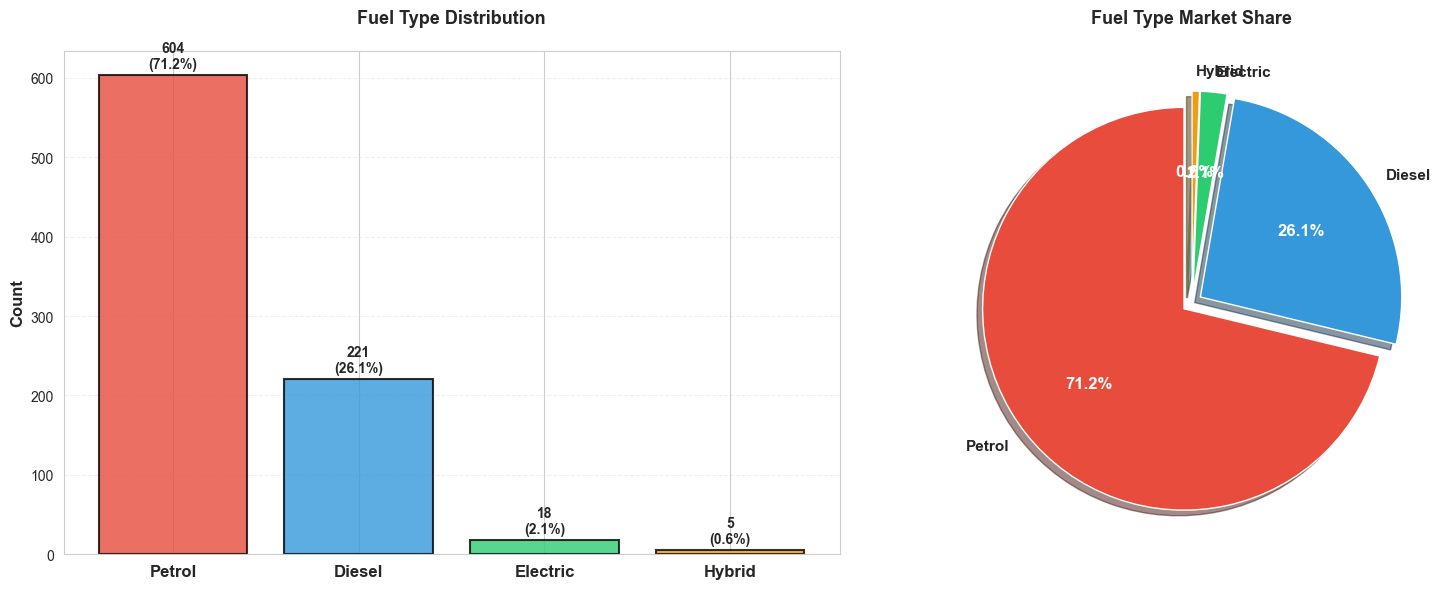


=== Fuel Type Distribution Summary ===
Total cars in dataset: 848

Breakdown by fuel type:
  Petrol: 604 cars (71.2%)
  Diesel: 221 cars (26.1%)
  Electric: 18 cars (2.1%)
  Hybrid: 5 cars (0.6%)

Conventional fuels (Petrol + Diesel): 825 cars (97.3%)
Alternative fuels (Electric + Hybrid): 23 cars (2.7%)
Alternative fuel adoption rate: 2.7%


In [17]:
# Visualize fuel type distribution
fuel_counts = car_dataset['Fuel'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = ax1.bar(range(len(fuel_counts)), fuel_counts.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(fuel_counts)))
ax1.set_xticklabels(fuel_counts.index, fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Fuel Type Distribution', fontsize=13, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}\n({height/len(car_dataset)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
explode = tuple([0.05] * len(fuel_counts))
wedges, texts, autotexts = ax2.pie(fuel_counts.values, 
                                     labels=fuel_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     shadow=True)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax2.set_title('Fuel Type Market Share', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('DataVisualisationAssets/Fuel_Type_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Fuel Type Distribution Summary ===")
print(f"Total cars in dataset: {len(car_dataset)}")
print(f"\nBreakdown by fuel type:")
for fuel_type, count in fuel_counts.items():
    percentage = count/len(car_dataset)*100
    print(f"  {fuel_type}: {count} cars ({percentage:.1f}%)")

# Calculate conventional vs alternative fuel vehicles
conventional = fuel_counts.get('Petrol', 0) + fuel_counts.get('Diesel', 0)
alternative = fuel_counts.get('Electric', 0) + fuel_counts.get('Hybrid', 0)
print(f"\nConventional fuels (Petrol + Diesel): {conventional} cars ({conventional/len(car_dataset)*100:.1f}%)")
print(f"Alternative fuels (Electric + Hybrid): {alternative} cars ({alternative/len(car_dataset)*100:.1f}%)")
print(f"Alternative fuel adoption rate: {alternative/len(car_dataset)*100:.1f}%")

### 4.3 'Brand' and 'Brand_Encoded' Column extraction

#### 4.3.1 Brand values extraction from 'Name'

In [18]:
# Verify how many Name values contain specifications in parentheses
import re

# Check for values with parentheses
has_parentheses = car_dataset['Name'].str.contains(r'\(.*\)', na=False)
count_with_parentheses = has_parentheses.sum()
total_count = len(car_dataset)

print(f"Total rows in dataset: {total_count}")
print(f"Rows with parentheses in Name: {count_with_parentheses}")
print(f"Rows without parentheses in Name: {total_count - count_with_parentheses}")

# Show examples without parentheses
print("\n--- Examples WITHOUT parentheses ---")
print(car_dataset[~has_parentheses]['Name'].head(10))

Total rows in dataset: 848
Rows with parentheses in Name: 844
Rows without parentheses in Name: 4

--- Examples WITHOUT parentheses ---
56                                    School Bus On Sale
233    Excellent Condition Maruti Suzuki Alto 800 On ...
290                             Scorpio Pick Up 2016 4wd
560            Single Handed Eeco 7 Seater 2018 For Sell
Name: Name, dtype: object


In [19]:
# Extract brand from parentheses
def extract_brand(name_str):
    if pd.isna(name_str):
        return None
    
    # Search for content within parentheses
    pattern = r'\(([^)]+)\)'
    match = re.search(pattern, name_str)
    
    if match:
        brand = match.group(1).strip()
        return brand
    else:
        # For entries without parentheses, try to extract first word as brand
        # Common brands in the dataset
        common_brands = ['Maruti', 'Suzuki', 'Hyundai', 'Tata', 'Mahindra', 'Toyota', 
                        'Honda', 'Ford', 'Nissan', 'Scorpio', 'Eeco', 'Alto']
        
        for brand in common_brands:
            if brand.lower() in name_str.lower():
                return brand
        
        # If no match, return first word
        first_word = name_str.split()[0] if name_str.split() else None
        return first_word

# Apply extraction
car_dataset['Brand'] = car_dataset['Name'].apply(extract_brand)

print("Brand extraction results:")
print(f"\nUnique brands found: {car_dataset['Brand'].nunique()}")
print(f"Null values in Brand: {car_dataset['Brand'].isna().sum()}")
print("\nTop 10 brands by count:")
print(car_dataset['Brand'].value_counts().head(10))

Brand extraction results:

Unique brands found: 55
Null values in Brand: 0

Top 10 brands by count:
Brand
Hyundai          199
Maruti Suzuki    182
Tata              78
Mahindra          65
Toyota            50
Kia               43
Ford              40
Other Brands      28
Volkswagen        24
Nissan            22
Name: count, dtype: int64


In [20]:
# the rows that originally didn't have parentheses
print("\n--- Rows that originally had no parentheses (edge cases) ---")
rows_without_parentheses_idx = [56, 233, 290, 560]
print(car_dataset.loc[rows_without_parentheses_idx, ['Name', 'Brand']])


--- Rows that originally had no parentheses (edge cases) ---
                                                  Name    Brand
56                                  School Bus On Sale   School
233  Excellent Condition Maruti Suzuki Alto 800 On ...   Maruti
290                           Scorpio Pick Up 2016 4wd  Scorpio
560          Single Handed Eeco 7 Seater 2018 For Sell     Eeco


#### 4.3.2 Brand_Encoded Column

In [21]:
# Create Brand_Encoded column in main dataset
from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder()
car_dataset['Brand_Encoded'] = le_brand.fit_transform(car_dataset['Brand'])

print("Brand_Encoded column created!")
print(f"\n--- Total unique brands: {len(le_brand.classes_)} ---")

brand_counts = car_dataset['Brand'].value_counts().head()
for brand in brand_counts.index:
    encoded_value = le_brand.transform([brand])[0]
    print(f"{brand}: {encoded_value}")

print("\n--- Sample Data ---")
print(car_dataset[['Brand', 'Brand_Encoded']].head(10))

Brand_Encoded column created!

--- Total unique brands: 55 ---
Hyundai: 24
Maruti Suzuki: 30
Tata: 45
Mahindra: 28
Toyota: 46

--- Sample Data ---
           Brand  Brand_Encoded
0        Hyundai             24
1        Hyundai             24
2           Tata             45
3       Mahindra             28
4        Hyundai             24
5           Tata             45
6           Tata             45
7  Maruti Suzuki             30
8        Hyundai             24
9  Maruti Suzuki             30


#### 4.3.3 Visualization: Brand Distribution

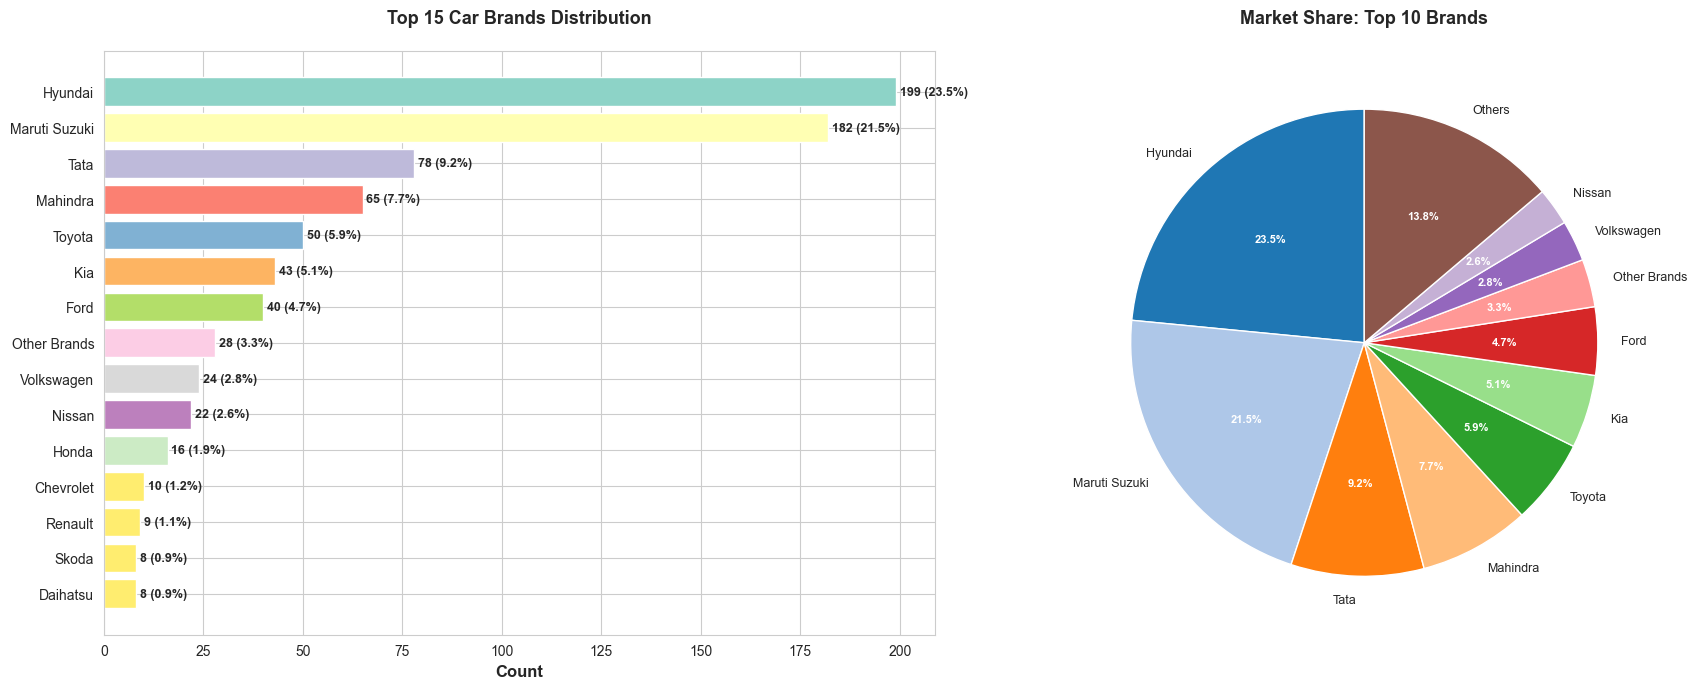


=== Brand Distribution Summary ===
Total unique brands: 55
Total cars in dataset: 848

Top 10 brands account for: 86.2% of all cars

Top 5 brands:
1. Hyundai: 199 cars (23.5%)
2. Maruti Suzuki: 182 cars (21.5%)
3. Tata: 78 cars (9.2%)
4. Mahindra: 65 cars (7.7%)
5. Toyota: 50 cars (5.9%)


In [22]:
# Visualize brand distribution
brand_counts = car_dataset['Brand'].value_counts()

# Get top 15 brands
top_brands = brand_counts.head(15)
other_count = brand_counts[15:].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart for top 15 brands
colors = plt.cm.Set3(range(len(top_brands)))
bars = ax1.barh(range(len(top_brands)), top_brands.values, color=colors)
ax1.set_yticks(range(len(top_brands)))
ax1.set_yticklabels(top_brands.index)
ax1.set_xlabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Car Brands Distribution', fontsize=13, fontweight='bold', pad=20)
ax1.invert_yaxis()  # Highest at top

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_brands.values)):
    ax1.text(value + 1, bar.get_y() + bar.get_height()/2, 
             f'{value} ({value/len(car_dataset)*100:.1f}%)',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Pie chart for market share
pie_data = list(top_brands.head(10).values) + [brand_counts[10:].sum()]
pie_labels = list(top_brands.head(10).index) + ['Others']
colors_pie = plt.cm.tab20(range(len(pie_data)))

wedges, texts, autotexts = ax2.pie(pie_data, 
                                     labels=pie_labels,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     startangle=90,
                                     textprops={'fontsize': 9})

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

ax2.set_title('Market Share: Top 10 Brands', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('DataVisualisationAssets/Brand_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Brand Distribution Summary ===")
print(f"Total unique brands: {car_dataset['Brand'].nunique()}")
print(f"Total cars in dataset: {len(car_dataset)}")
print(f"\nTop 10 brands account for: {top_brands.head(10).sum()/len(car_dataset)*100:.1f}% of all cars")
print(f"\nTop 5 brands:")
for i, (brand, count) in enumerate(top_brands.head(5).items(), 1):
    print(f"{i}. {brand}: {count} cars ({count/len(car_dataset)*100:.1f}%)")

### 4.4 'Price' Column Analysis and Cleaning

#### 4.4.1 'Price' Column data values analysis

In [23]:
car_dataset['Price'].value_counts()

Price
रू. 15,00,000                 19
रू. 12,50,000                 18
रू. 14,00,000                 16
रू. 17,00,000                 13
रू. 9,50,000                  12
                              ..
रू. 57,50,000रू. 58,00,000     1
रू. 36,75,000                  1
रू. 7,15,000                   1
रू. 7,99,999                   1
रू. 19,25,000                  1
Name: count, Length: 316, dtype: int64

In [24]:
car_dataset['Price'].unique()

array(['रू. 24,75,000रू. 25,00,000', 'रू. 7,50,000', 'रू. 7,00,000',
       'रू. 6,00,000', 'रू. 375', 'रू. 14,00,000', 'रू. 5,80,000',
       'रू. 18,45,000', 'रू. 20,50,000', 'रू. 10,25,000', 'रू. 13,50,000',
       'रू. 12,50,000', 'रू. 32,50,000', 'रू. 19,50,000', 'रू. 32,00,000',
       'रू. 25,00,000', 'रू. 51,00,000', 'रू. 53,00,000', 'रू. 58,00,000',
       'रू. 23,50,000', 'रू. 18,50,000', 'रू. 14,30,000', 'रू. 26,00,000',
       'रू. 37,50,000', 'रू. 17,80,000', 'रू. 13,60,000', 'रू. 9,50,000',
       'रू. 26,50,000', 'रू. 78,50,000', 'रू. 12,75,000', 'रू. 24,00,000',
       'रू. 13,00,000', 'रू. 29,50,000', 'रू. 15,50,077', 'रू. 35,25,000',
       'रू. 34,50,000', 'रू. 5,50,000', 'रू. 15,00,000', 'रू. 6,40,000',
       'रू. 33,99,000', 'रू. 5,75,000', 'रू. 28,50,000', 'रू. 10,50,000',
       'रू. 7,49,000', 'रू. 43,00,000', 'रू. 8,95,000', 'रू. 4,75,000',
       'रू. 18,25,000', 'रू. 21,00,000', 'रू. 24,50,000', 'रू. 15,99,999',
       'रू. 44,99,999', 'रू. 97,00,000', 'रू. 

#### 4.4.2 Cleaning the 'Price' column by:
- Removing currency symbol using regex.
- Replacing data having two different values with their average.

In [25]:
# Clean Price column - remove Rupee symbol and handle multiple prices
import re

def clean_price(price_str):
    if pd.isna(price_str):
        return None
    
    price_str = str(price_str)
    
    # Find all numbers in the format of currency (with commas)
    pattern = r'[\d,]+'
    matches = re.findall(pattern, price_str)
    
    # Convert matched strings to integers (remove commas)
    numbers = []
    for match in matches:
        cleaned = match.replace(',', '').strip()
        if cleaned.isdigit() and len(cleaned) > 2:  # Filter out small numbers
            numbers.append(int(cleaned))
    
    # If multiple prices found, return average; otherwise return the single price
    if len(numbers) > 1:
        return sum(numbers) / len(numbers)
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return None

# Apply the cleaning function
car_dataset['Price_Cleaned'] = car_dataset['Price'].apply(clean_price)

# Check the results
print("Original vs Cleaned Price (first 10):")
print(car_dataset[['Price', 'Price_Cleaned']].head(10))

Original vs Cleaned Price (first 10):
                        Price  Price_Cleaned
0  रू. 24,75,000रू. 25,00,000      2487500.0
1                रू. 7,50,000       750000.0
2                रू. 7,00,000       700000.0
3                रू. 6,00,000       600000.0
4                     रू. 375          375.0
5               रू. 14,00,000      1400000.0
6                रू. 7,00,000       700000.0
7                रू. 5,80,000       580000.0
8               रू. 18,45,000      1845000.0
9               रू. 20,50,000      2050000.0


In [26]:
# Verify the cleaning worked - show some examples with multiple prices
print("\nExamples with multiple prices:")
multiple_prices = car_dataset[car_dataset['Price'].str.contains('रू.*रू', na=False)][['Price', 'Price_Cleaned']].head()
print(multiple_prices)


Examples with multiple prices:
                          Price  Price_Cleaned
0    रू. 24,75,000रू. 25,00,000      2487500.0
704  रू. 57,50,000रू. 58,00,000      5775000.0
735  रू. 30,50,000रू. 30,75,000      3062500.0
762  रू. 24,50,000रू. 24,75,000      2462500.0
793  रू. 20,25,000रू. 20,50,000      2037500.0


#### 4.4.3 Outlier Check

(array([586., 191.,  42.,  15.,   9.,   1.,   1.,   1.,   0.,   2.]),
 array([3.75000000e+02, 2.40033750e+06, 4.80030000e+06, 7.20026250e+06,
        9.60022500e+06, 1.20001875e+07, 1.44001500e+07, 1.68001125e+07,
        1.92000750e+07, 2.16000375e+07, 2.40000000e+07]),
 <BarContainer object of 10 artists>)

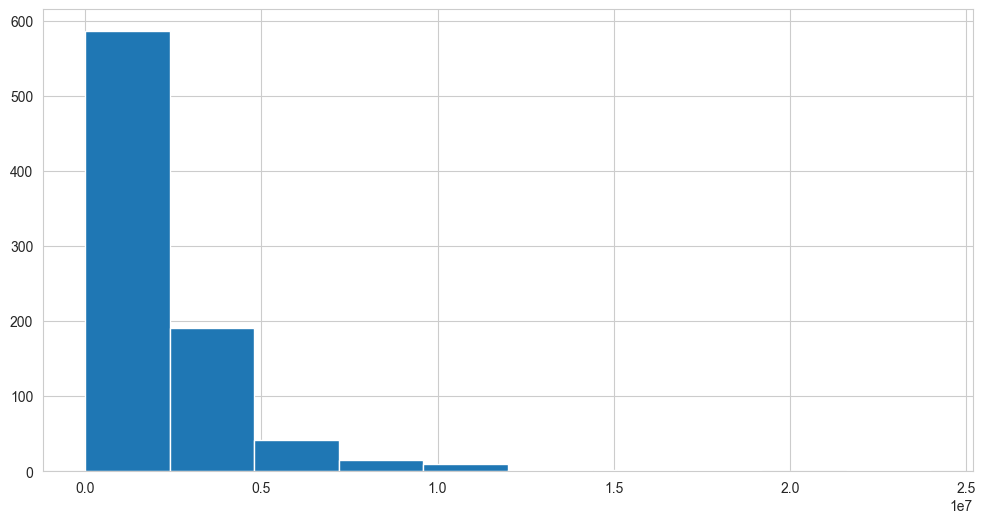

In [30]:
plt.hist(car_dataset['Price_Cleaned'])

In [31]:
car_dataset['Price_Cleaned'].describe()

count    8.480000e+02
mean     2.339459e+06
std      2.182332e+06
min      3.750000e+02
25%      1.175000e+06
50%      1.760000e+06
75%      2.661250e+06
max      2.400000e+07
Name: Price_Cleaned, dtype: float64

In [32]:
# Check for suspiciously low prices (likely errors)
print(f"\nMinimum price: {car_dataset['Price_Cleaned'].min()}")
print(f"\nMaximum price: {car_dataset['Price_Cleaned'].max()}")

low_prices = car_dataset[car_dataset['Price_Cleaned'] == car_dataset['Price_Cleaned'].min()][['Name', 'Price', 'Price_Cleaned']]
print(low_prices)
high_price = car_dataset[car_dataset['Price_Cleaned'] == car_dataset['Price_Cleaned'].max()][['Name', 'Price', 'Price_Cleaned']]
print(high_price)



Minimum price: 375.0

Maximum price: 24000000.0
                                          Name    Price  Price_Cleaned
4  i20 Active good for used few time (Hyundai)  रू. 375          375.0
                                          Name            Price  Price_Cleaned
293  Land cruiser Prado vx 2017 model (Toyota)  रू. 2,40,00,000     24000000.0


In [33]:
# Remove rows with unrealistic prices (< 100,000 NPR as threshold)
print(f"Dataset size before cleaning: {len(car_dataset)}")

car_dataset = car_dataset[car_dataset['Price_Cleaned'] >= 100000]

print(f"Dataset size after removing low prices: {len(car_dataset)}")
print(f"Rows removed: {len(car_dataset[car_dataset['Price_Cleaned'] < 100000]) if len(car_dataset[car_dataset['Price_Cleaned'] < 100000]) > 0 else 'Already cleaned'}")
print(f"\nNew minimum price: {car_dataset['Price_Cleaned'].min()}")

Dataset size before cleaning: 848
Dataset size after removing low prices: 847
Rows removed: Already cleaned

New minimum price: 150000.0


### 4.5 'Transmission' Column Analysis and Cleaning

#### 4.5.1 'Transmission' column values analysis

In [34]:
car_dataset['Transmisson'].value_counts()

Transmisson
Manual - 2WD      297
Manual2WD         218
Auto2WD            69
Manual - 4WD       66
Auto - 2WD         62
Manual4WD          42
Power Steering     28
Auto4WD            25
Auto - 4WD         23
PowerSteering      17
Name: count, dtype: int64

In [35]:
car_dataset['Transmisson'].unique()

array(['Manual2WD', 'Auto2WD', 'Manual - 2WD', 'Manual - 4WD', 'Auto4WD',
       'Manual4WD', 'Auto - 2WD', 'Auto - 4WD', 'PowerSteering',
       'Power Steering'], dtype=object)

#### 4.5.2 Cleaning 'Transmission' column values

In [36]:
# Clean Transmission column - standardize formats
def clean_transmission(trans_str):
    if pd.isna(trans_str):
        return None
    
    # Convert to string and remove spaces and hyphens
    trans_str = str(trans_str).replace(' ', '').replace('-', '').strip()
    
    return trans_str

# Apply cleaning
car_dataset['Transmisson_Cleaned'] = car_dataset['Transmisson'].apply(clean_transmission)

print("\nTransmission values after cleaning:")
print(car_dataset['Transmisson_Cleaned'].unique())
print("\nValue counts after cleaning:")
print(car_dataset['Transmisson_Cleaned'].value_counts())


Transmission values after cleaning:
['Manual2WD' 'Auto2WD' 'Manual4WD' 'Auto4WD' 'PowerSteering']

Value counts after cleaning:
Transmisson_Cleaned
Manual2WD        515
Auto2WD          131
Manual4WD        108
Auto4WD           48
PowerSteering     45
Name: count, dtype: int64


#### 4.5.3 Transmission_Encoded Column

In [37]:
# Create Transmission_Encoded column in main dataset

le_transmission = LabelEncoder()
car_dataset['Transmission_Encoded'] = le_transmission.fit_transform(car_dataset['Transmisson_Cleaned'])

print("Transmission_Encoded column created!")
print("\n--- Transmission Encoding Mapping ---")
for i, trans_type in enumerate(le_transmission.classes_):
    print(f"{trans_type}: {i}")

print("\n--- Sample Data ---")
print(car_dataset[['Name', 'Transmission_Encoded']].head(10))

Transmission_Encoded column created!

--- Transmission Encoding Mapping ---
Auto2WD: 0
Auto4WD: 1
Manual2WD: 2
Manual4WD: 3
PowerSteering: 4

--- Sample Data ---
                                                 Name  Transmission_Encoded
0   Hyundai | i20 Active S | TDi | 2015 | Hatchbac...                     2
1                     Excellent car on sale (Hyundai)                     0
2                           TATA 407 Container (Tata)                     2
3                         4x4 swaraj Mazda (Mahindra)                     3
5                       Tata Sumo Gold 2014 GX (Tata)                     2
6                           Mega XL hatti gadi (Tata)                     0
7     Maruti Suzuki Alto 2004 On Sale (Maruti Suzuki)                     2
8                      Grand i10 magna 2014 (Hyundai)                     2
9       Blue colour 2016 model Baleno (Maruti Suzuki)                     1
10                WagonR Sell or Rent (Maruti Suzuki)                     2


#### 4.5.4 Visualization: Transmission Distribution

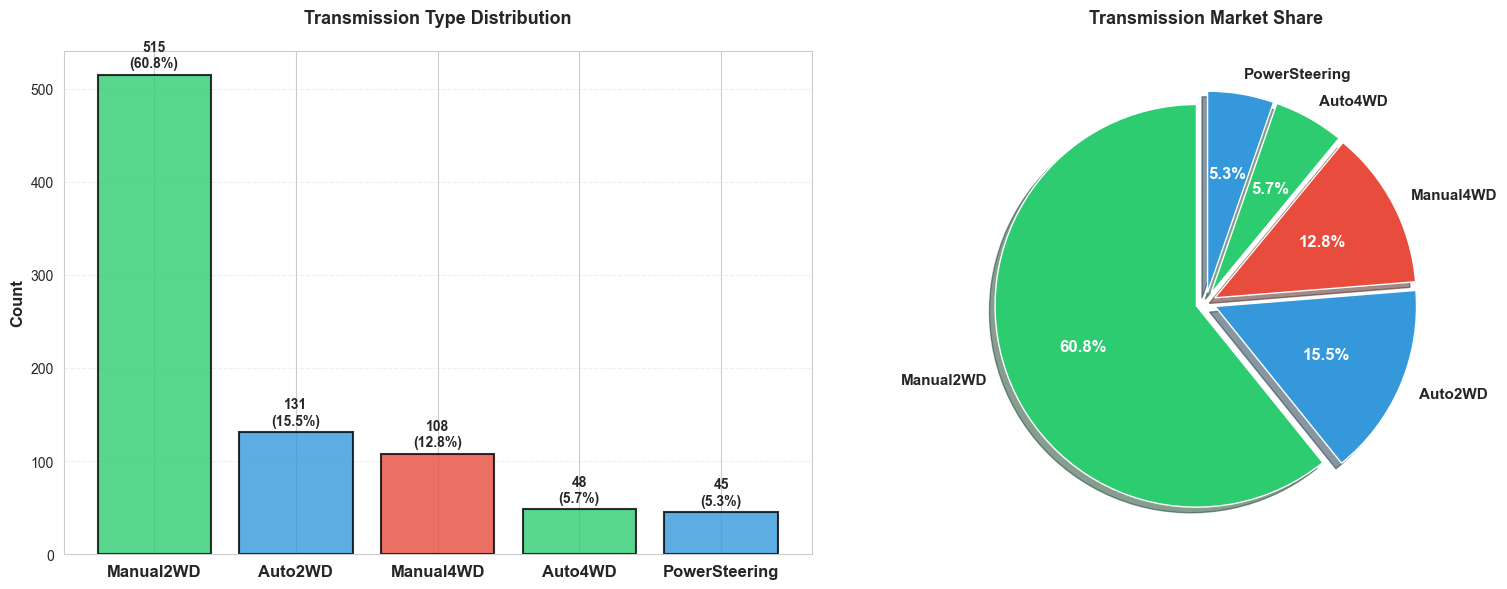


=== Transmission Distribution Summary ===
Total cars in dataset: 847

Breakdown by transmission type:
  Manual2WD: 515 cars (60.8%)
  Auto2WD: 131 cars (15.5%)
  Manual4WD: 108 cars (12.8%)
  Auto4WD: 48 cars (5.7%)
  PowerSteering: 45 cars (5.3%)


In [38]:
# Visualize transmission distribution
transmission_counts = car_dataset['Transmisson_Cleaned'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax1.bar(range(len(transmission_counts)), transmission_counts.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(transmission_counts)))
ax1.set_xticklabels(transmission_counts.index, fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Transmission Type Distribution', fontsize=13, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}\n({height/len(car_dataset)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
explode = tuple([0.05] * len(transmission_counts))
wedges, texts, autotexts = ax2.pie(transmission_counts.values, 
                                     labels=transmission_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     shadow=True)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax2.set_title('Transmission Market Share', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('DataVisualisationAssets/Transmission_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Transmission Distribution Summary ===")
print(f"Total cars in dataset: {len(car_dataset)}")
print(f"\nBreakdown by transmission type:")
for trans_type, count in transmission_counts.items():
    percentage = count/len(car_dataset)*100
    print(f"  {trans_type}: {count} cars ({percentage:.1f}%)")

# Calculate automatic vs manual ratio
if 'Automatic' in transmission_counts.index and 'Manual' in transmission_counts.index:
    auto_count = transmission_counts['Automatic']
    manual_count = transmission_counts['Manual']
    ratio = auto_count / manual_count
    print(f"\nAutomatic to Manual ratio: {ratio:.2f}:1")
    if auto_count > manual_count:
        print(f"Automatic transmissions are {(auto_count/manual_count - 1)*100:.1f}% more common than Manual")
    else:
        print(f"Manual transmissions are {(manual_count/auto_count - 1)*100:.1f}% more common than Automatic")

### 4.6 'Colour' column analysis and cleaning 

#### 4.6.1 'Colour' column data values analysis

In [39]:
car_dataset['Colour'].value_counts()

Colour
White                        100
Silver                        86
silver                        78
white                         61
Grey                          44
                            ... 
Satine silver                  1
Metallic Grey                  1
Navy blue                      1
Carbon Steel ( Dark Grey)      1
cream                          1
Name: count, Length: 182, dtype: int64

#### 4.6.2 Filling in the Null values with 'Not Specified' value.

In [40]:
# Fill missing values in Colour column
print(f"Missing values in Colour before: {car_dataset['Colour'].isna().sum()}")

car_dataset['Colour'].fillna('Not Specified', inplace=True)

print(f"Missing values in Colour after: {car_dataset['Colour'].isna().sum()}")
print("\nUpdated Colour value counts:")
print(car_dataset['Colour'].value_counts())

Missing values in Colour before: 82
Missing values in Colour after: 0

Updated Colour value counts:
Colour
White                        100
Silver                        86
Not Specified                 82
silver                        78
white                         61
                            ... 
Satine silver                  1
Metallic Grey                  1
Navy blue                      1
Carbon Steel ( Dark Grey)      1
cream                          1
Name: count, Length: 183, dtype: int64


C:\Users\ACER\AppData\Local\Temp\ipykernel_12200\3577523117.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_dataset['Colour'].fillna('Not Specified', inplace=True)


### 4.7 'Make Year' Column Analysis and Cleaning

#### 4.7.1 'Make Year' column data values analysis

In [41]:
car_dataset['Make Year'].unique()

array(['2015', '2005', '2013', '2017', '2014', '2019', '2004', '2016',
       '2008', '2010', '2018', '2011', '2021', '2009', '2003', '2002',
       '1997', '2023', '2007', '2006', '2012', '2020', '2022', '2000',
       '1975', '2001', '1998', '2006 november', 'Tata zest XT 2015 model',
       '1999', '0', '2069', '207', '1992', '2060', '202', '13', '2015`',
       '1993', '2021 last mdel'], dtype=object)

In [42]:
car_dataset['Make Year'].value_counts()

Make Year
2016                       80
2017                       74
2010                       65
2021                       64
2015                       60
2018                       60
2014                       58
2009                       47
2013                       40
2007                       37
2019                       34
2008                       31
2011                       30
2012                       29
2020                       25
2006                       16
2005                       13
2004                       11
2003                       11
2023                        9
2022                        8
2002                        7
2001                        7
2000                        5
1998                        4
1997                        3
1999                        3
1975                        2
0                           2
207                         2
Tata zest XT 2015 model     1
2006 november               1
2069                        1


#### 4.7.2 Column cleaning with:
- Using regex for year extraction.
- Handling BS to AD for standardization.

In [43]:
# Clean Make Year column
def clean_make_year(year_str):
    if pd.isna(year_str):
        return None
    
    year_str = str(year_str).strip()
    
    # Extract first 4-digit number (year)
    pattern = r'(\d{4})'
    match = re.search(pattern, year_str)
    
    if match:
        year = int(match.group(1))
        
        # Handle Nepali calendar years (2000-2100 BS = 1943-2043 AD approximately)
        # Convert BS to AD: BS - 57 = AD (approximate)
        if year >= 2043 and year <= 2100:  # Nepali calendar range
            year = year - 57
        
        # Validate reasonable year range (1975-2025 for cars)
        if 1975 <= year <= 2025:
            return year
        else:
            return None
    else:
        return None

# Apply cleaning
car_dataset['Make_Year_Cleaned'] = car_dataset['Make Year'].apply(clean_make_year)

# Convert to integer type (Int64 allows NaN values)
car_dataset['Make_Year_Cleaned'] = car_dataset['Make_Year_Cleaned'].astype('Int64')

# Show results
print(f"\nRows with invalid years (will be None): {car_dataset['Make_Year_Cleaned'].isna().sum()}")


Rows with invalid years (will be None): 6


In [44]:
car_dataset['Make_Year_Cleaned'].unique()

<IntegerArray>
[2015, 2005, 2013, 2017, 2014, 2019, 2004, 2016, 2008, 2010, 2018, 2011, 2021,
 2009, 2003, 2002, 1997, 2023, 2007, 2006, 2012, 2020, 2022, 2000, 1975, 2001,
 1998, 1999, <NA>, 1992, 1993]
Length: 31, dtype: Int64

#### 4.7.3 Manual analysis and Cleaning for invalid cases

In [45]:
# Show rows with invalid years (None/NaN after cleaning)
invalid_years = car_dataset[car_dataset['Make_Year_Cleaned'].isna()][['Name', 'Make Year', 'Make_Year_Cleaned']]
print(f"Total rows with invalid years: {len(invalid_years)}")
print("\nRows with invalid Make Year values:")
print(invalid_years)

Total rows with invalid years: 6

Rows with invalid Make Year values:
                                                Name Make Year  \
488                  Toyota AVANZA 7 Seater (Toyota)         0   
565                  TOYOTA AVANZA 7 Seater (Toyota)         0   
575              2017 Hyundai Eon Era Plus (Hyundai)       207   
711  Mahindra maximo HD series 2020 model (Mahindra)       202   
757                              Skoda rapid (Skoda)        13   
805                               Toyota LX (Toyota)       207   

     Make_Year_Cleaned  
488               <NA>  
565               <NA>  
575               <NA>  
711               <NA>  
757               <NA>  
805               <NA>  


In [46]:
# Manually fix specific invalid year values
car_dataset.loc[car_dataset['Make Year'] == '0', 'Make_Year_Cleaned'] = 2000
car_dataset.loc[car_dataset['Make Year'] == '207', 'Make_Year_Cleaned'] = 2007
car_dataset.loc[car_dataset['Make Year'] == '202', 'Make_Year_Cleaned'] = 2002
car_dataset.loc[car_dataset['Make Year'] == '13', 'Make_Year_Cleaned'] = 2013

print("Manual replacements applied:")
print("'0' → 2000")
print("'207' → 2007")
print("'202' → 2002")
print("'13' → 2013")
print(f"\nRows with invalid years after manual fixes: {car_dataset['Make_Year_Cleaned'].isna().sum()}")

Manual replacements applied:
'0' → 2000
'207' → 2007
'202' → 2002
'13' → 2013

Rows with invalid years after manual fixes: 0


In [47]:
car_dataset['Make_Year_Cleaned'].unique()

<IntegerArray>
[2015, 2005, 2013, 2017, 2014, 2019, 2004, 2016, 2008, 2010, 2018, 2011, 2021,
 2009, 2003, 2002, 1997, 2023, 2007, 2006, 2012, 2020, 2022, 2000, 1975, 2001,
 1998, 1999, 1992, 1993]
Length: 30, dtype: Int64

### 4.8 'Engine (CC)' Column Analysis and Cleaning

#### 4.8.1 'Engine (CC)' column data values analysis

In [48]:
car_dataset['Engine (CC)'].unique()

array(['1400', '1399', '2956', nan, '2956cc', '889', '800', '1200',
       '1100', '2500', '2100', '2499', '105', '1197', '1582', '1193',
       '2.8', '1086', '1500', '1368', '1299', '2000', '999', '1000',
       '1600', '3700', '3783', '250', '30KW BATTERY', '1084', '1300',
       '1248', '1948', '1956', '30', '2882', '2400', '1599', '2900',
       '2800', '2523', '1.8', '2179', '3500', '2200', '1383', '995',
       '1198', '996', '1405', '1196', '15000', '3000', '2169', '1499',
       '2967', '1591', '1596', '702', '1298', '2700', '4898', '1096',
       '796', '700', '1186', '850', '814', '5223', '100kw', '1991',
       '2157', '1497', '1656', '998', '1998', '2950', '2999', '3200',
       '2600', '1075', '1047', '110 kw', '2495', '1997', '1462', '1699',
       '1061', '1896', '1496', '1199', '1350', '1498', '600', '1598',
       '2500 cc', '5883', '993', '624', '1191cc', '1198cc', '1995cc',
       '4461', '1984', '1200cc', '2494', '2755', '15', '10000', '2199',
       '1992', '2362'

#### 4.8.2 kW to CC Conversion
**Note on kW to CC Conversion:**
- Based on 'a 100 kW electric motor is about 134 hp'.
- For a Typical Mid-range car, 134 hp ≈ (1800 - 2300) CC / Avg 2000
- Electric motors measured in kW have been converted to equivalent CC using the formula: **1 kW ≈ 20 CC**
- This is an approximate industry standard conversion for comparison purposes
- Additional thresholding for suspiciously low values for specific fuel types.

In [49]:
# Clean Engine (CC) column - convert all values to CC (including kW to CC conversion)
def clean_engine_to_cc(engine_str, fuel_type):
    if pd.isna(engine_str):
        return None
    
    engine_str = str(engine_str).strip()
    
    # Extract numeric value
    pattern = r'(\d+\.?\d*)'
    match = re.search(pattern, engine_str)
    
    if match:
        value = float(match.group(1))
        
        # If Electric, check if value is in kW or already in CC
        if fuel_type == 'Electric':
            # Check if the string explicitly contains 'kw' or 'KW'
            if 'kw' in engine_str.lower():
                # It's definitely in kW, convert to CC (1 kW ≈ 20 CC)
                cc_value = value * 20
                return cc_value
            # If value is > 500, it's likely already in CC (reasonable engine size)
            elif value > 500:
                return value  # Already in CC
            # If value is <= 500 and doesn't specify unit, assume it's kW
            else:
                cc_value = value * 20  # Convert kW to CC
                return cc_value
        else:
            return value  # Already in CC for conventional cars
    else:
        return None

# Apply cleaning - create unified Engine_Cleaned_CC column
car_dataset['Engine_Cleaned_CC'] = car_dataset.apply(
    lambda row: clean_engine_to_cc(row['Engine (CC)'], row['Fuel']),
    axis=1
)

print("Engine cleaning results (unified CC column):")
print(f"\nElectric cars (kW converted to CC):")
print(car_dataset[car_dataset['Fuel'] == 'Electric'][['Fuel', 'Engine (CC)', 'Engine_Cleaned_CC']].head(10))

Engine cleaning results (unified CC column):

Electric cars (kW converted to CC):
         Fuel   Engine (CC)  Engine_Cleaned_CC
15   Electric          2100             2100.0
18   Electric           105             2100.0
19   Electric           NaN                NaN
65   Electric  30KW BATTERY              600.0
87   Electric            30              600.0
138  Electric           NaN                NaN
186  Electric           NaN                NaN
218  Electric           NaN                NaN
254  Electric           NaN                NaN
281  Electric         100kw             2000.0


#### 4.8.3 Verification: Electric Cars - Which values were converted vs kept as CC

In [50]:
# Show electric cars with original values and how they were handled
electric_cars_engine = car_dataset[car_dataset['Fuel'] == 'Electric'][['Engine (CC)', 'Engine_Cleaned_CC']].copy()

# Add column to show if it was converted or kept
def check_conversion(row):
    if pd.notna(row['Engine (CC)']):
        original_str = str(row['Engine (CC)']).strip()
        pattern = r'(\d+\.?\d*)'
        match = re.search(pattern, original_str)
        if match:
            original_value = float(match.group(1))
            cleaned_value = row['Engine_Cleaned_CC']
            
            if pd.notna(cleaned_value):
                # If they're equal, it was kept as CC
                if abs(original_value - cleaned_value) < 1:
                    return 'Kept as CC'
                # If cleaned is about 20x original, it was converted
                elif abs(cleaned_value - (original_value * 20)) < 10:
                    return f'Converted (kW→CC)'
                else:
                    return 'Unknown'
    return 'N/A'

electric_cars_engine['Conversion_Status'] = electric_cars_engine.apply(check_conversion, axis=1)

print("Electric Cars - Engine Value Handling:")
print("="*80)
print(electric_cars_engine.to_string())
print("\n--- Summary ---")
print(electric_cars_engine['Conversion_Status'].value_counts())

Electric Cars - Engine Value Handling:
      Engine (CC)  Engine_Cleaned_CC  Conversion_Status
15           2100             2100.0         Kept as CC
18            105             2100.0  Converted (kW→CC)
19            NaN                NaN                N/A
65   30KW BATTERY              600.0  Converted (kW→CC)
87             30              600.0  Converted (kW→CC)
138           NaN                NaN                N/A
186           NaN                NaN                N/A
218           NaN                NaN                N/A
254           NaN                NaN                N/A
281         100kw             2000.0  Converted (kW→CC)
289           NaN                NaN                N/A
356        110 kw             2200.0  Converted (kW→CC)
407           NaN                NaN                N/A
534            15              300.0  Converted (kW→CC)
553           NaN                NaN                N/A
556           NaN                NaN                N/A
665      

#### 4.8.4 Filling in the Null Values in Engine (CC) by KNN Imputation (Sophisticated - Uses Multiple Features)

In [51]:
# KNN Imputation using Price, Year, Fuel type (without Mileage dependency)
from sklearn.impute import KNNImputer

car_dataset_KNNmethod = car_dataset.copy()

# Selected features that correlate with engine size
features_for_knn = car_dataset_KNNmethod[[
    'Fuel_Encoded',
    'Transmission_Encoded',
    'Brand_Encoded',
    'Make_Year_Cleaned', 
    'Price_Cleaned',
    'Engine_Cleaned_CC'
]].copy()

# Apply KNN Imputer (k=5 neighbors)
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_array = knn_imputer.fit_transform(features_for_knn)

# Extract imputed engine column
car_dataset_KNNmethod['Engine_KNN'] = imputed_array[:, -1].round(0)

print(f"Remaining nulls: {car_dataset_KNNmethod['Engine_KNN'].isna().sum()}")
print("\n--- Features Used: Fuel type, Transmission, Brand, Make Year, and Price to find similar cars ---")

Remaining nulls: 0

--- Features Used: Fuel type, Transmission, Brand, Make Year, and Price to find similar cars ---


In [52]:
# Apply the KNN imputed values to the main dataset's Engine_Cleaned_CC column
car_dataset['Engine_Cleaned_CC'] = car_dataset_KNNmethod['Engine_KNN']

print(f"Null values in Engine_Cleaned_CC after KNN imputation: {car_dataset['Engine_Cleaned_CC'].isna().sum()}")
print(f"\nEngine_Cleaned_CC statistics after filling:")
print(car_dataset['Engine_Cleaned_CC'].describe())

Null values in Engine_Cleaned_CC after KNN imputation: 0

Engine_Cleaned_CC statistics after filling:
count      847.000000
mean      1533.721370
std        854.038498
min          0.000000
25%       1197.000000
50%       1259.000000
75%       1658.500000
max      15000.000000
Name: Engine_Cleaned_CC, dtype: float64


(array([519., 301.,  21.,   4.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([    0.,  1500.,  3000.,  4500.,  6000.,  7500.,  9000., 10500.,
        12000., 13500., 15000.]),
 <BarContainer object of 10 artists>)

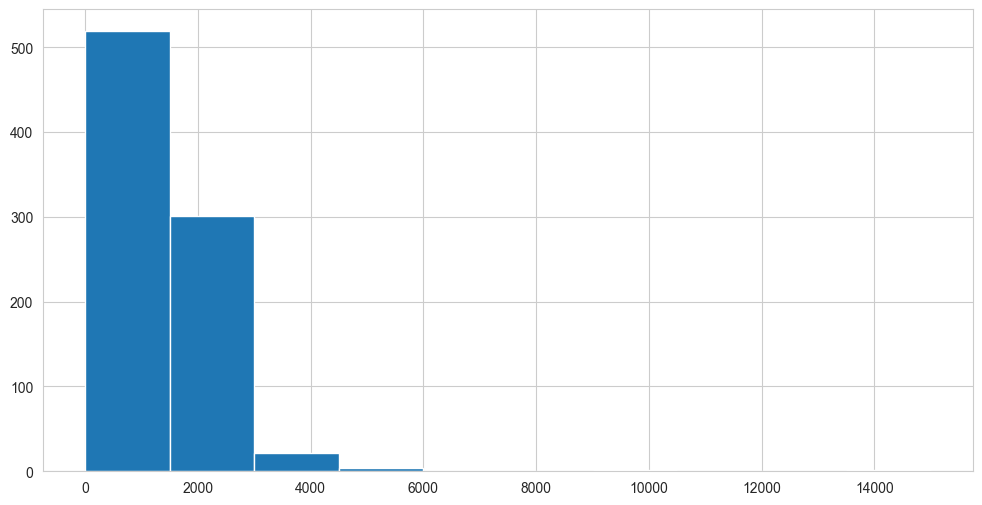

In [54]:
plt.hist(car_dataset['Engine_Cleaned_CC'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1fd4fd7d190>,
 'caps': [<matplotlib.lines.Line2D at 0x1fd4fd7d6d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fd4fd7cf80>],
 'medians': [<matplotlib.lines.Line2D at 0x1fd4fd7dac0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fd4fd7dd60>],
 'means': []}

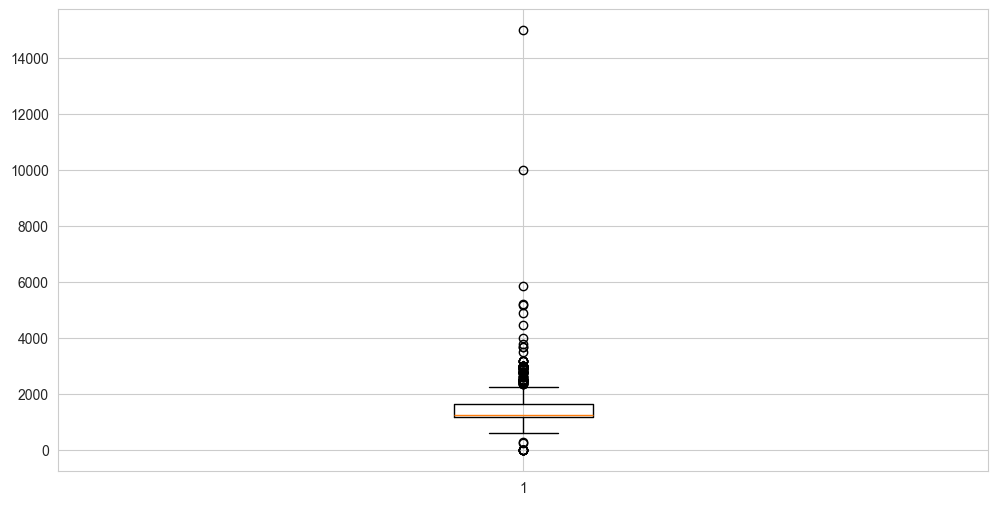

In [55]:
plt.boxplot(car_dataset['Engine_Cleaned_CC'])

#### 4.8.5 Setting Systematic Thresholds for Engine CC

Realistic engine size thresholds by fuel type:

**Minimum thresholds:**
- **Petrol/Diesel/Hybrid**: Minimum ~600 CC (small cars like Alto, Wagon R)
- **Electric**: Minimum ~300 CC equivalent (after kW conversion)

**Maximum thresholds:**
- **Petrol/Diesel/Hybrid**: Maximum ~6,000 CC (large SUVs, luxury cars, performance vehicles)
- **Electric**: Maximum ~3,000 CC equivalent (high-performance electric vehicles)

Any values outside these thresholds are likely errors and should be imputed.

In [56]:
# Define realistic thresholds for engine size by fuel type
MIN_ENGINE_CONVENTIONAL = 600   # CC for Petrol/Diesel/Hybrid
MAX_ENGINE_CONVENTIONAL = 6000  # CC for Petrol/Diesel/Hybrid (large SUVs, luxury cars)
MIN_ENGINE_ELECTRIC = 300       # CC equivalent for Electric
MAX_ENGINE_ELECTRIC = 3000      # CC equivalent for Electric (high-performance EVs)

# Check current values outside thresholds
print("=== Current Engine Values Outside Realistic Thresholds ===\n")

# Check minimum thresholds
conventional_below = car_dataset[
    (car_dataset['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])) & 
    (car_dataset['Engine_Cleaned_CC'] < MIN_ENGINE_CONVENTIONAL)
]
electric_below = car_dataset[
    (car_dataset['Fuel'] == 'Electric') & 
    (car_dataset['Engine_Cleaned_CC'] < MIN_ENGINE_ELECTRIC)
]

# Check maximum thresholds
conventional_above = car_dataset[
    (car_dataset['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])) & 
    (car_dataset['Engine_Cleaned_CC'] > MAX_ENGINE_CONVENTIONAL)
]
electric_above = car_dataset[
    (car_dataset['Fuel'] == 'Electric') & 
    (car_dataset['Engine_Cleaned_CC'] > MAX_ENGINE_ELECTRIC)
]

print(f"Petrol/Diesel/Hybrid cars with engine < {MIN_ENGINE_CONVENTIONAL} CC: {len(conventional_below)}")
if len(conventional_below) > 0:
    print(conventional_below[['Name', 'Fuel', 'Engine_Cleaned_CC']].head(10))

print(f"\nPetrol/Diesel/Hybrid cars with engine > {MAX_ENGINE_CONVENTIONAL} CC: {len(conventional_above)}")
if len(conventional_above) > 0:
    print(conventional_above[['Name', 'Fuel', 'Engine_Cleaned_CC', 'Price_Cleaned']].head(10))

print(f"\nElectric cars with engine < {MIN_ENGINE_ELECTRIC} CC: {len(electric_below)}")
if len(electric_below) > 0:
    print(electric_below[['Name', 'Fuel', 'Engine_Cleaned_CC']].head(10))

print(f"\nElectric cars with engine > {MAX_ENGINE_ELECTRIC} CC: {len(electric_above)}")
if len(electric_above) > 0:
    print(electric_above[['Name', 'Fuel', 'Engine_Cleaned_CC']].head(10))

total_outliers = len(conventional_below) + len(conventional_above) + len(electric_below) + len(electric_above)
print(f"\n--- Total rows needing threshold correction: {total_outliers} ---")
print(f"Percentage of dataset: {total_outliers/len(car_dataset)*100:.2f}%")

# Show current Engine CC distribution statistics
print(f"\n=== Current Engine CC Statistics ===")
print(f"Overall: Min={car_dataset['Engine_Cleaned_CC'].min():.0f} CC, Max={car_dataset['Engine_Cleaned_CC'].max():.0f} CC")
print(f"Petrol/Diesel/Hybrid: Min={car_dataset[car_dataset['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])]['Engine_Cleaned_CC'].min():.0f} CC, Max={car_dataset[car_dataset['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])]['Engine_Cleaned_CC'].max():.0f} CC")
print(f"Electric: Min={car_dataset[car_dataset['Fuel']=='Electric']['Engine_Cleaned_CC'].min():.0f} CC, Max={car_dataset[car_dataset['Fuel']=='Electric']['Engine_Cleaned_CC'].max():.0f} CC")

=== Current Engine Values Outside Realistic Thresholds ===

Petrol/Diesel/Hybrid cars with engine < 600 CC: 9
                                                  Name    Fuel  \
30    Toyota hilux revo 2018 sell or exchange (Toyota)  Diesel   
59   Nissan sunny 2014 full option sedan for sale (...  Petrol   
104          Skoda yeti in excellent condition (Skoda)  Petrol   
633              Very Fresh Car for Sale(2016) (Skoda)  Diesel   
684  4w Suv On Sale In Very Very Barand New Conditi...  Diesel   
763                       Creta 2017 On sale (Hyundai)  Petrol   
777                                     Sell (Hyundai)  Petrol   
826          Tata manza car sale and exchange (Toyota)  Diesel   
835               Naza Forza 2008 Model (Other Brands)  Petrol   

     Engine_Cleaned_CC  
30                 3.0  
59               250.0  
104                2.0  
633                1.0  
684                0.0  
763                2.0  
777                1.0  
826               15.0  
835 

In [57]:
# Replace values outside thresholds with NaN, then re-impute
car_dataset_threshold = car_dataset.copy()

# Mark values BELOW minimum thresholds as NaN
car_dataset_threshold.loc[
    (car_dataset_threshold['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])) & 
    (car_dataset_threshold['Engine_Cleaned_CC'] < MIN_ENGINE_CONVENTIONAL),
    'Engine_Cleaned_CC'
] = None

car_dataset_threshold.loc[
    (car_dataset_threshold['Fuel'] == 'Electric') & 
    (car_dataset_threshold['Engine_Cleaned_CC'] < MIN_ENGINE_ELECTRIC),
    'Engine_Cleaned_CC'
] = None

# Mark values ABOVE maximum thresholds as NaN
car_dataset_threshold.loc[
    (car_dataset_threshold['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])) & 
    (car_dataset_threshold['Engine_Cleaned_CC'] > MAX_ENGINE_CONVENTIONAL),
    'Engine_Cleaned_CC'
] = None

car_dataset_threshold.loc[
    (car_dataset_threshold['Fuel'] == 'Electric') & 
    (car_dataset_threshold['Engine_Cleaned_CC'] > MAX_ENGINE_ELECTRIC),
    'Engine_Cleaned_CC'
] = None

print(f"Values below threshold replaced with NaN")
print(f"Total null values to impute: {car_dataset_threshold['Engine_Cleaned_CC'].isna().sum()}")

# Re-run KNN imputation with threshold corrections
features_for_knn_threshold = car_dataset_threshold[[
    'Fuel_Encoded',
    'Transmission_Encoded',
    'Brand_Encoded',
    'Make_Year_Cleaned', 
    'Price_Cleaned',
    'Engine_Cleaned_CC'
]].copy()

knn_imputer_threshold = KNNImputer(n_neighbors=5, weights='distance')
imputed_array_threshold = knn_imputer_threshold.fit_transform(features_for_knn_threshold)

# Extract imputed values
car_dataset_threshold['Engine_Cleaned_CC'] = imputed_array_threshold[:, -1].round(0)

print(f"\n=== After Threshold-Based KNN Imputation ===")
print(f"Null values: {car_dataset_threshold['Engine_Cleaned_CC'].isna().sum()}")
print(f"\nEngine_Cleaned_CC statistics:")
print(car_dataset_threshold['Engine_Cleaned_CC'].describe())

Values below threshold replaced with NaN
Total null values to impute: 11

=== After Threshold-Based KNN Imputation ===
Null values: 0

Engine_Cleaned_CC statistics:
count     847.000000
mean     1523.994097
std       638.931215
min       300.000000
25%      1197.000000
50%      1298.000000
75%      1665.500000
max      5883.000000
Name: Engine_Cleaned_CC, dtype: float64


#### 4.8.5 Applying the threshold-corrected Engine values back to main dataset

In [58]:
# Apply the threshold-corrected values back to main dataset
car_dataset['Engine_Cleaned_CC'] = car_dataset_threshold['Engine_Cleaned_CC']

print("✓ Engine_Cleaned_CC updated with systematic threshold validation!")
print(f"\n=== Final Verification ===")
print(f"Null values: {car_dataset['Engine_Cleaned_CC'].isna().sum()}")
print(f"Min value: {car_dataset['Engine_Cleaned_CC'].min():.0f} CC")
print(f"Max value: {car_dataset['Engine_Cleaned_CC'].max():.0f} CC")

# Verify no values outside thresholds remain
conventional_still_below = car_dataset[
    (car_dataset['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])) & 
    (car_dataset['Engine_Cleaned_CC'] < MIN_ENGINE_CONVENTIONAL)
]
conventional_still_above = car_dataset[
    (car_dataset['Fuel'].isin(['Petrol', 'Diesel', 'Hybrid'])) & 
    (car_dataset['Engine_Cleaned_CC'] > MAX_ENGINE_CONVENTIONAL)
]
electric_still_below = car_dataset[
    (car_dataset['Fuel'] == 'Electric') & 
    (car_dataset['Engine_Cleaned_CC'] < MIN_ENGINE_ELECTRIC)
]
electric_still_above = car_dataset[
    (car_dataset['Fuel'] == 'Electric') & 
    (car_dataset['Engine_Cleaned_CC'] > MAX_ENGINE_ELECTRIC)
]

print(f"\n✓ Conventional fuel cars below {MIN_ENGINE_CONVENTIONAL} CC: {len(conventional_still_below)}")
print(f"✓ Conventional fuel cars above {MAX_ENGINE_CONVENTIONAL} CC: {len(conventional_still_above)}")
print(f"✓ Electric cars below {MIN_ENGINE_ELECTRIC} CC: {len(electric_still_below)}")
print(f"✓ Electric cars above {MAX_ENGINE_ELECTRIC} CC: {len(electric_still_above)}")

total_still_outside = len(conventional_still_below) + len(conventional_still_above) + len(electric_still_below) + len(electric_still_above)
if total_still_outside == 0:
    print("\n✓ All engine values are now within realistic thresholds!")
else:
    print(f"\n⚠ Warning: {total_still_outside} values still outside thresholds")
    
print(f"\n=== Final Engine CC Statistics ===")
print(f"Overall: Min={car_dataset['Engine_Cleaned_CC'].min():.0f} CC, Max={car_dataset['Engine_Cleaned_CC'].max():.0f} CC")
print(f"Mean: {car_dataset['Engine_Cleaned_CC'].mean():.0f} CC")
print(f"Median: {car_dataset['Engine_Cleaned_CC'].median():.0f} CC")

✓ Engine_Cleaned_CC updated with systematic threshold validation!

=== Final Verification ===
Null values: 0
Min value: 300 CC
Max value: 5883 CC

✓ Conventional fuel cars below 600 CC: 0
✓ Conventional fuel cars above 6000 CC: 0
✓ Electric cars below 300 CC: 0
✓ Electric cars above 3000 CC: 0

✓ All engine values are now within realistic thresholds!

=== Final Engine CC Statistics ===
Overall: Min=300 CC, Max=5883 CC
Mean: 1524 CC
Median: 1298 CC


### 4.9 'Kilometer Run' Column Analysis and Cleaning

#### 4.9.1 'Kilometer Run' column data values analysis

In [59]:
car_dataset['Kilometer Run'].unique()

array(['42000', '87412', '60000', nan, '80000', '75000', '31000', '41000',
       '43000', '4200', '65000', '61000', '51000', '12200', '9000',
       '7000', '45000', '59000', '18300', '53000', '29000', '48000',
       '26000', '57000', '13750', '750840', '52000', '70000', '67000',
       '38000', '71000', '74000', '24000', '39888', '34200', '30000',
       '42500', '3700', '16777', '55708', '6000', '57560', '55000',
       '35200', '6700', '93726', '47000', '9500', '24800', '14500',
       '32000', '12000', '46543', '34000', '11000', '0', '62000', '25000',
       '23000', '17000', '72000', '60500', '45400', '8000', '62370',
       '58000', '35000', '5500', '50000', '97500', '40000', '25125',
       '100000', '95000', '90000', '89', '95', '10000', '39000', '61477',
       '46000', '27000', '78000', '610000', '28000', '70', '64000',
       '21000', '28500', '5600', '20000', '98000', '36000', '5900',
       '38300', '36200', '56000', '73000', '130000', '20', '86000',
       '40352', '820

#### 4.9.2 Numeric Value Extraction

In [60]:
# Clean Kilometer Run column - extract numeric values
def clean_kilometer_run(km_str):
    if pd.isna(km_str):
        return None
    
    km_str = str(km_str).strip()
    
    # Extract numeric value
    pattern = r'(\d+\.?\d*)'
    match = re.search(pattern, km_str)
    
    if match:
        return float(match.group(1))
    else:
        return None

# Apply cleaning
car_dataset['Kilometer_Run_Cleaned'] = car_dataset['Kilometer Run'].apply(clean_kilometer_run)

print("Kilometer Run cleaning results:")
print(car_dataset[['Kilometer Run', 'Kilometer_Run_Cleaned']].head(10))
print(f"\nNull values after cleaning: {car_dataset['Kilometer_Run_Cleaned'].isna().sum()}")

Kilometer Run cleaning results:
   Kilometer Run  Kilometer_Run_Cleaned
0          42000                42000.0
1          87412                87412.0
2          60000                60000.0
3            NaN                    NaN
5            NaN                    NaN
6          80000                80000.0
7          75000                75000.0
8          31000                31000.0
9          41000                41000.0
10         43000                43000.0

Null values after cleaning: 143


#### 4.9.3 KNN Imputation for Kilometer Run

KNN imputation based on:
- **Make Year** (older cars → higher km)
- **Price** (lower price → higher km)  
- **Brand** (usage patterns vary by brand)
- **Transmission** (manual/automatic usage differences)
- **Fuel Type** (diesel often used for long distances)

In [61]:
# KNN Imputation for Kilometer Run using correlated features
car_dataset_km_knn = car_dataset.copy()

# Features that correlate with kilometer run
features_for_km_knn = car_dataset_km_knn[[
    'Make_Year_Cleaned',
    'Price_Cleaned',
    'Brand_Encoded',
    'Transmission_Encoded',
    'Fuel_Encoded',
    'Kilometer_Run_Cleaned'
]].copy()

# Apply KNN Imputer
knn_imputer_km = KNNImputer(n_neighbors=5, weights='distance')
imputed_km_array = knn_imputer_km.fit_transform(features_for_km_knn)

# Extract imputed kilometer run column
car_dataset_km_knn['Kilometer_Run_KNN'] = imputed_km_array[:, -1].round(2)

print("=== KNN Imputation for Kilometer Run ===")
print(f"Null values remaining: {car_dataset_km_knn['Kilometer_Run_KNN'].isna().sum()}")

print("\n--- Features used: Make Year, Price, Brand, Transmission, Fuel Type ---")

=== KNN Imputation for Kilometer Run ===
Null values remaining: 0

--- Features used: Make Year, Price, Brand, Transmission, Fuel Type ---


In [62]:
# Apply KNN imputed values to main dataset

car_dataset['Kilometer_Run_Cleaned'] = car_dataset_km_knn['Kilometer_Run_KNN']
print("Kilometer_Run_Cleaned updated with KNN imputed values!")
print(f"Null values: {car_dataset['Kilometer_Run_Cleaned'].isna().sum()}")
print(f"\nUpdated statistics:")
print(car_dataset['Kilometer_Run_Cleaned'].describe())
print(car_dataset['Kilometer_Run_Cleaned'].max())
print(car_dataset['Kilometer_Run_Cleaned'].min())

Kilometer_Run_Cleaned updated with KNN imputed values!
Null values: 0

Updated statistics:
count    8.470000e+02
mean     5.807323e+04
std      9.313923e+04
min      0.000000e+00
25%      3.499854e+04
50%      4.942765e+04
75%      6.600000e+04
max      1.700000e+06
Name: Kilometer_Run_Cleaned, dtype: float64
1700000.0
0.0


#### 4.9.4 Systematic Threshold for Kilometer Run (Odometer Reading)

Realistic thresholds for odometer readings:
- **Minimum**: 50 km (brand new/barely driven cars exist, but 0 km is unrealistic for used cars)
- **Maximum**: 500,000 km (while some commercial vehicles may exceed this, most passenger cars are retired or heavily depreciated beyond this point)

Typical realistic range:
- New/Nearly New: 100 - 10,000 km
- Low Mileage: 10,000 - 50,000 km
- Average Usage: 50,000 - 150,000 km
- High Mileage: 150,000 - 300,000 km
- Very High (Commercial/Old): 300,000 - 500,000 km

Values outside 100 - 500,000 km range will be treated as outliers and re-imputed.

In [65]:
MIN_ODOMETER_KM = 100      # Minimum realistic km for used cars
below_min = car_dataset[car_dataset['Kilometer_Run_Cleaned'] < MIN_ODOMETER_KM]

print(f"Cars with odometer < {MIN_ODOMETER_KM} km: {len(below_min)}")
if len(below_min) > 0:
    print(below_min[['Make_Year_Cleaned', 'Kilometer_Run_Cleaned']].head(10))

Cars with odometer < 100 km: 17
     Make_Year_Cleaned  Kilometer_Run_Cleaned
95                2009                    0.0
135               2002                   89.0
136               2001                   95.0
141               2005                   45.0
180               2014                   70.0
230               2007                   20.0
341               2009                   67.0
360               2017                   70.0
422               2001                   75.0
524               2015                    9.0


In [66]:
# Define realistic thresholds for odometer readings
MIN_ODOMETER_KM = 10      # Minimum realistic km for used cars
MAX_ODOMETER_KM = 500000   # Maximum realistic km for passenger cars

# Check current values outside threshold
print("=== Current Odometer Values Outside Realistic Thresholds ===\n")

below_min = car_dataset[car_dataset['Kilometer_Run_Cleaned'] < MIN_ODOMETER_KM]
above_max = car_dataset[car_dataset['Kilometer_Run_Cleaned'] > MAX_ODOMETER_KM]

print(f"Cars with odometer < {MIN_ODOMETER_KM} km: {len(below_min)}")
if len(below_min) > 0:
    print(below_min[['Name', 'Make_Year_Cleaned', 'Kilometer_Run_Cleaned']].head(10))

print(f"\nCars with odometer > {MAX_ODOMETER_KM} km: {len(above_max)}")
if len(above_max) > 0:
    print(above_max[['Name', 'Make_Year_Cleaned', 'Price_Cleaned', 'Kilometer_Run_Cleaned']].head(10))

total_outliers = len(below_min) + len(above_max)
print(f"\n--- Total rows needing threshold correction: {total_outliers} ---")
print(f"Percentage of dataset: {total_outliers/len(car_dataset)*100:.2f}%")

=== Current Odometer Values Outside Realistic Thresholds ===

Cars with odometer < 10 km: 4
                                               Name  Make_Year_Cleaned  \
95   Fresh Mini Jeep On Sell (Other Chinese Brands)               2009   
524               urgent sale 9841395832 (Mahindra)               2015   
553           New Electric taxi booking open (Tata)               2023   
819                    Ford India, Eco Sport (Ford)               2013   

     Kilometer_Run_Cleaned  
95                     0.0  
524                    9.0  
553                    0.0  
819                    0.0  

Cars with odometer > 500000 km: 7
                                                  Name  Make_Year_Cleaned  \
37                              Scorpio S4+ (Mahindra)               2016   
175                   Suzuki cargo van (Maruti Suzuki)               2014   
267              14 model Bolero is in sale (Mahindra)               2014   
311                        yodha ba 18 cha 2125 (

#### 4.9.5 Replacing values outside threshold with NaN, then re-impute

In [67]:
# Create copy for threshold-based correction
car_dataset_km_threshold = car_dataset.copy()

# Mark values outside threshold as NaN
car_dataset_km_threshold.loc[
    car_dataset_km_threshold['Kilometer_Run_Cleaned'] < MIN_ODOMETER_KM,
    'Kilometer_Run_Cleaned'
] = None

car_dataset_km_threshold.loc[
    car_dataset_km_threshold['Kilometer_Run_Cleaned'] > MAX_ODOMETER_KM,
    'Kilometer_Run_Cleaned'
] = None

print(f"Values outside threshold replaced with NaN")
print(f"Total null values to impute: {car_dataset_km_threshold['Kilometer_Run_Cleaned'].isna().sum()}")

# Re-run KNN imputation with threshold corrections
features_for_km_threshold = car_dataset_km_threshold[[
    'Make_Year_Cleaned',
    'Price_Cleaned',
    'Brand_Encoded',
    'Transmission_Encoded',
    'Fuel_Encoded',
    'Kilometer_Run_Cleaned'
]].copy()

knn_imputer_km_threshold = KNNImputer(n_neighbors=5, weights='distance')
imputed_km_threshold_array = knn_imputer_km_threshold.fit_transform(features_for_km_threshold)

# Extract imputed values
car_dataset_km_threshold['Kilometer_Run_Cleaned'] = imputed_km_threshold_array[:, -1].round(2)

print(f"\n=== After Threshold-Based KNN Imputation ===")
print(f"Null values: {car_dataset_km_threshold['Kilometer_Run_Cleaned'].isna().sum()}")
print(f"Min value: {car_dataset_km_threshold['Kilometer_Run_Cleaned'].min():.2f} km")
print(f"Max value: {car_dataset_km_threshold['Kilometer_Run_Cleaned'].max():.2f} km")
print(f"\nKilometer_Run_Cleaned statistics:")
print(car_dataset_km_threshold['Kilometer_Run_Cleaned'].describe())

Values outside threshold replaced with NaN
Total null values to impute: 11

=== After Threshold-Based KNN Imputation ===
Null values: 0
Min value: 20.00 km
Max value: 485780.00 km

Kilometer_Run_Cleaned statistics:
count       847.000000
mean      51111.612834
std       32101.274081
min          20.000000
25%       35000.000000
50%       49427.650000
75%       65000.000000
max      485780.000000
Name: Kilometer_Run_Cleaned, dtype: float64


#### 4.9.6 Applying the threshold-corrected Odometer values back to main dataset

In [68]:
# Apply the threshold-corrected values back to main dataset
car_dataset['Kilometer_Run_Cleaned'] = car_dataset_km_threshold['Kilometer_Run_Cleaned']

print("✓ Kilometer_Run_Cleaned updated with systematic threshold validation!")
print(f"\n=== Final Verification ===")
print(f"Null values: {car_dataset['Kilometer_Run_Cleaned'].isna().sum()}")
print(f"Min value: {car_dataset['Kilometer_Run_Cleaned'].min():.2f} km")
print(f"Max value: {car_dataset['Kilometer_Run_Cleaned'].max():.2f} km")

# Verify no values outside thresholds remain
still_below_min = car_dataset[car_dataset['Kilometer_Run_Cleaned'] < MIN_ODOMETER_KM]
still_above_max = car_dataset[car_dataset['Kilometer_Run_Cleaned'] > MAX_ODOMETER_KM]

print(f"\n✓ Cars below {MIN_ODOMETER_KM} km: {len(still_below_min)}")
print(f"✓ Cars above {MAX_ODOMETER_KM} km: {len(still_above_max)}")

if len(still_below_min) == 0 and len(still_above_max) == 0:
    print("\nAll odometer readings are now within realistic thresholds!")
else:
    print(f"\nNote: {len(still_below_min) + len(still_above_max)} values still outside thresholds")
    
# Show distribution summary
print("\n=== Odometer Reading Distribution ===")
print(f"Nearly New (< 10,000 km): {len(car_dataset[car_dataset['Kilometer_Run_Cleaned'] < 10000])} cars ({len(car_dataset[car_dataset['Kilometer_Run_Cleaned'] < 10000])/len(car_dataset)*100:.1f}%)")
print(f"Low Mileage (10,000 - 50,000 km): {len(car_dataset[(car_dataset['Kilometer_Run_Cleaned'] >= 10000) & (car_dataset['Kilometer_Run_Cleaned'] < 50000)])} cars")
print(f"Average (50,000 - 150,000 km): {len(car_dataset[(car_dataset['Kilometer_Run_Cleaned'] >= 50000) & (car_dataset['Kilometer_Run_Cleaned'] < 150000)])} cars")
print(f"High Mileage (150,000 - 300,000 km): {len(car_dataset[(car_dataset['Kilometer_Run_Cleaned'] >= 150000) & (car_dataset['Kilometer_Run_Cleaned'] < 300000)])} cars")
print(f"Very High (300,000 - 500,000 km): {len(car_dataset[(car_dataset['Kilometer_Run_Cleaned'] >= 300000) & (car_dataset['Kilometer_Run_Cleaned'] <= 500000)])} cars")

✓ Kilometer_Run_Cleaned updated with systematic threshold validation!

=== Final Verification ===
Null values: 0
Min value: 20.00 km
Max value: 485780.00 km

✓ Cars below 10 km: 0
✓ Cars above 500000 km: 0

All odometer readings are now within realistic thresholds!

=== Odometer Reading Distribution ===
Nearly New (< 10,000 km): 58 cars (6.8%)
Low Mileage (10,000 - 50,000 km): 369 cars
Average (50,000 - 150,000 km): 412 cars
High Mileage (150,000 - 300,000 km): 6 cars
Very High (300,000 - 500,000 km): 2 cars


### 4.10 'Mileage' Column Analysis and Cleaning

#### 4.10.1 'Mileage' column data values analysis

In [69]:
car_dataset['Mileage'].value_counts()

Mileage
15          62
14          61
12          59
18          35
16          34
            ..
20kmpl       1
15000        1
+12km        1
12km         1
12 km/he     1
Name: count, Length: 87, dtype: int64

In [70]:
car_dataset['Mileage'].unique()

array(['14', '11', nan, '12', '15', '17/18 km', '20', '14+', '300', '18',
       '13', '21.4', '10', '18/20', '16', '17', '5', '3800', '160',
       '15 km/l', '13-15', '10 to 15', '270', '7', '12km.ltr', '18 kmpl',
       '20-21', '550', '13-Dec', '19', '22', '270+ in one full charge',
       '16-17', '12 to 14', '69000', '50', 'Good', '16-18', '6, 7',
       '14/15', '50000', '15-Dec', '13-18', 'Per full charge 400 km',
       '12-Oct', '22 km/l', '17.5', '14-Dec', '70k', '15 KMPL', 'N/a',
       '10 to 12', '13 plus', '14-15', '40', '17/18',
       '15.3 (As shown on the average counter display)', '12Km/Pl',
       '19-20', '8', '12-Aug', '120', '29.87', '16/17', '16.5', '14 km',
       '13-Oct', '2025', '16-20 kmpl', '10-Aug', '21', '17-19km/l',
       '15km/ltr', '25', '10-Sep', '18 Km per liter', '23', '15 above',
       '27km/ltr', '27.97', '20-22', '16 in city', '9 km/kwh', '20kmpl',
       '15000', '+12km', '12km', '12 km/he'], dtype=object)

#### 4.10.2 String separation and km scaling for given values (Only string values returned in Null)

In [71]:
# Clean Mileage column - extract numbers and scale to km
def clean_mileage(mileage_str):
    if pd.isna(mileage_str):
        return None
    
    mileage_str = str(mileage_str).strip()
    
    # Extract first number (integer or decimal)
    pattern = r'(\d+\.?\d*)'
    match = re.search(pattern, mileage_str)
    
    if match:
        mileage = float(match.group(1))
        
        # Scale values over 1000 by dividing by 1000 (assuming they're in meters or similar)
        if mileage > 1000:
            mileage = mileage / 1000
        
        return mileage
    else:
        # Return None if no numeric value found (pure string values)
        return None

# Apply cleaning
car_dataset['Mileage_Cleaned'] = car_dataset['Mileage'].apply(clean_mileage)
# Check statistics and unique values after cleaning
print(f"\nNull values after cleaning: {car_dataset['Mileage_Cleaned'].isna().sum()}")
car_dataset['Mileage_Cleaned'].unique()


Null values after cleaning: 393


array([ 14.   ,  11.   ,     nan,  12.   ,  15.   ,  17.   ,  20.   ,
       300.   ,  18.   ,  13.   ,  21.4  ,  10.   ,  16.   ,   5.   ,
         3.8  , 160.   , 270.   ,   7.   , 550.   ,  19.   ,  22.   ,
        69.   ,  50.   ,   6.   , 400.   ,  17.5  ,  70.   ,  40.   ,
        15.3  ,   8.   , 120.   ,  29.87 ,  16.5  ,   2.025,  21.   ,
        25.   ,  23.   ,  27.   ,  27.97 ,   9.   ])

#### 4.10.3 KNN Imputation for Mileage (Fuel Efficiency)

Use KNN imputation based on features that strongly correlate with fuel efficiency:
- **Engine Size (CC)** - Larger engines → lower mileage
- **Fuel Type** - Electric/Hybrid → higher efficiency
- **Transmission** - Manual typically more efficient than automatic
- **Make Year** - Newer technology → better efficiency
- **Brand** - Brand-specific engineering standards

In [72]:
# KNN Imputation for Mileage using correlated features
car_dataset_mileage_knn = car_dataset.copy()

# Features that correlate with mileage (fuel efficiency)
features_for_mileage_knn = car_dataset_mileage_knn[[
    'Engine_Cleaned_CC',
    'Fuel_Encoded',
    'Transmission_Encoded',
    'Make_Year_Cleaned',
    'Brand_Encoded',
    'Mileage_Cleaned'
]].copy()

# Apply KNN Imputer
knn_imputer_mileage = KNNImputer(n_neighbors=5, weights='distance')
imputed_mileage_array = knn_imputer_mileage.fit_transform(features_for_mileage_knn)

# Extract imputed mileage column
car_dataset_mileage_knn['Mileage_KNN'] = imputed_mileage_array[:, -1].round(2)

print("=== KNN Imputation for Mileage (Fuel Efficiency) ===")
print(f"Null values remaining: {car_dataset_mileage_knn['Mileage_KNN'].isna().sum()}")
print(f"\nMileage_KNN statistics:")
print(car_dataset_mileage_knn['Mileage_KNN'].describe())
print("\n--- Features used: Engine CC, Fuel Type, Transmission, Make Year, Brand ---")

=== KNN Imputation for Mileage (Fuel Efficiency) ===
Null values remaining: 0

Mileage_KNN statistics:
count    847.000000
mean      18.854805
std       33.145098
min        2.020000
25%       12.440000
50%       14.000000
75%       16.000000
max      550.000000
Name: Mileage_KNN, dtype: float64

--- Features used: Engine CC, Fuel Type, Transmission, Make Year, Brand ---


In [73]:
# Show examples of imputed values with context
null_mask_mileage = car_dataset['Mileage_Cleaned'].isna()

if null_mask_mileage.sum() > 0:
    print("=== Examples of Mileage Imputation ===\n")
    
    comparison_mileage_df = pd.DataFrame({
        'Name': car_dataset.loc[null_mask_mileage, 'Name'],
        'Brand': car_dataset.loc[null_mask_mileage, 'Brand'],
        'Engine_CC': car_dataset.loc[null_mask_mileage, 'Engine_Cleaned_CC'],
        'Fuel': car_dataset.loc[null_mask_mileage, 'Fuel'],
        'Year': car_dataset.loc[null_mask_mileage, 'Make_Year_Cleaned'],
        'KNN_Mileage': car_dataset_mileage_knn.loc[null_mask_mileage, 'Mileage_KNN']
    })
    
    print(f"Total null values imputed: {null_mask_mileage.sum()}\n")
    print("Sample of imputed mileage values (first 15):")
    print(comparison_mileage_df.head(15).to_string(index=False))
    
    print("\n--- KNN predicts mileage based on similar cars with same engine size, fuel type, etc. ---")
else:
    print("No null values found - Mileage_Cleaned already filled!")

=== Examples of Mileage Imputation ===

Total null values imputed: 393

Sample of imputed mileage values (first 15):
                                                       Name         Brand  Engine_CC     Fuel  Year  KNN_Mileage
                                  TATA 407 Container (Tata)          Tata     2956.0   Diesel  2013        12.54
                                4x4 swaraj Mazda (Mahindra)      Mahindra     1181.0   Diesel  2017        13.93
            Maruti Suzuki Alto 2004 On Sale (Maruti Suzuki) Maruti Suzuki      800.0   Petrol  2004        69.00
                             Grand i10 magna 2014 (Hyundai)       Hyundai     1200.0   Petrol  2014        14.00
        2010 model red color santro zinc for sale (Hyundai)       Hyundai     1100.0   Petrol  2010        13.42
                                Mahindra cabking (Mahindra)      Mahindra      948.0   Diesel  2018        16.76
    2011 model ko kia sportage sales & exchange offer (Kia)           Kia     2000.0   Diese

In [74]:
# Apply KNN imputed values to main dataset
car_dataset['Mileage_Cleaned'] = car_dataset_mileage_knn['Mileage_KNN']

print("✓ Mileage_Cleaned updated with KNN imputed values!")
print(f"\nFinal verification:")
print(f"Null values: {car_dataset['Mileage_Cleaned'].isna().sum()}")
print(f"Min value: {car_dataset['Mileage_Cleaned'].min():.2f} km/L")
print(f"Max value: {car_dataset['Mileage_Cleaned'].max():.2f} km/L")
print(f"\nMileage_Cleaned statistics:")
print(car_dataset['Mileage_Cleaned'].describe())

✓ Mileage_Cleaned updated with KNN imputed values!

Final verification:
Null values: 0
Min value: 2.02 km/L
Max value: 550.00 km/L

Mileage_Cleaned statistics:
count    847.000000
mean      18.854805
std       33.145098
min        2.020000
25%       12.440000
50%       14.000000
75%       16.000000
max      550.000000
Name: Mileage_Cleaned, dtype: float64


#### 4.10.4 Systematic Minimum Threshold for Mileage

Realistic minimum mileage (fuel efficiency) by fuel type:
- **Petrol/Diesel**: Minimum ~5 km (even performance cars achieve this)
- **Hybrid/Electric**: Minimum ~10 km (hybrid advantage, electric efficiency)

Values below these thresholds are likely errors and should be re-imputed.

In [75]:
# Define realistic minimum thresholds for mileage by fuel type
MIN_MILEAGE_PETROL_DIESEL = 5.0   # km/L
MIN_MILEAGE_HYBRID = 10.0          # km/L  
MIN_MILEAGE_ELECTRIC = 10.0        # km equivalent

# Check current values below threshold
print("=== Current Mileage Values Below Realistic Thresholds ===\n")

petrol_diesel_below = car_dataset[
    (car_dataset['Fuel'].isin(['Petrol', 'Diesel'])) & 
    (car_dataset['Mileage_Cleaned'] < MIN_MILEAGE_PETROL_DIESEL)
]
hybrid_below = car_dataset[
    (car_dataset['Fuel'] == 'Hybrid') & 
    (car_dataset['Mileage_Cleaned'] < MIN_MILEAGE_HYBRID)
]
electric_below = car_dataset[
    (car_dataset['Fuel'] == 'Electric') & 
    (car_dataset['Mileage_Cleaned'] < MIN_MILEAGE_ELECTRIC)
]

print(f"Petrol/Diesel cars with mileage < {MIN_MILEAGE_PETROL_DIESEL} km/L: {len(petrol_diesel_below)}")
if len(petrol_diesel_below) > 0:
    print(petrol_diesel_below[['Name', 'Fuel', 'Engine_Cleaned_CC', 'Mileage_Cleaned']].head(10))

print(f"\nHybrid cars with mileage < {MIN_MILEAGE_HYBRID} km/L: {len(hybrid_below)}")
if len(hybrid_below) > 0:
    print(hybrid_below[['Name', 'Fuel', 'Engine_Cleaned_CC', 'Mileage_Cleaned']].head(10))

print(f"\nElectric cars with mileage < {MIN_MILEAGE_ELECTRIC} km/L: {len(electric_below)}")
if len(electric_below) > 0:
    print(electric_below[['Name', 'Fuel', 'Engine_Cleaned_CC', 'Mileage_Cleaned']].head(10))

total_below = len(petrol_diesel_below) + len(hybrid_below) + len(electric_below)
print(f"\n--- Total rows needing threshold correction: {total_below} ---")

=== Current Mileage Values Below Realistic Thresholds ===

Petrol/Diesel cars with mileage < 5.0 km/L: 3
                              Name    Fuel  Engine_Cleaned_CC  Mileage_Cleaned
60   Nissan kicks XV 2021 (Nissan)  Petrol             2449.0             3.80
630          Hyundai i10 (Hyundai)  Petrol             1200.0             2.02
843    Hyundai grand i10 (Hyundai)  Petrol             1200.0             2.02

Hybrid cars with mileage < 10.0 km/L: 0

Electric cars with mileage < 10.0 km/L: 1
                               Name      Fuel  Engine_Cleaned_CC  \
774  Kia Soul EV 2017 on sale (Kia)  Electric             1740.0   

     Mileage_Cleaned  
774              9.0  

--- Total rows needing threshold correction: 4 ---


#### 4.10.5 Replacing values below threshold with NaN, then re-impute

In [76]:
car_dataset_mileage_threshold = car_dataset.copy()

# Mark values below threshold as NaN based on fuel type
car_dataset_mileage_threshold.loc[
    (car_dataset_mileage_threshold['Fuel'].isin(['Petrol', 'Diesel'])) & 
    (car_dataset_mileage_threshold['Mileage_Cleaned'] < MIN_MILEAGE_PETROL_DIESEL),
    'Mileage_Cleaned'
] = None

car_dataset_mileage_threshold.loc[
    (car_dataset_mileage_threshold['Fuel'] == 'Hybrid') & 
    (car_dataset_mileage_threshold['Mileage_Cleaned'] < MIN_MILEAGE_HYBRID),
    'Mileage_Cleaned'
] = None

car_dataset_mileage_threshold.loc[
    (car_dataset_mileage_threshold['Fuel'] == 'Electric') & 
    (car_dataset_mileage_threshold['Mileage_Cleaned'] < MIN_MILEAGE_ELECTRIC),
    'Mileage_Cleaned'
] = None

print(f"Values below threshold replaced with NaN")
print(f"Total null values to impute: {car_dataset_mileage_threshold['Mileage_Cleaned'].isna().sum()}")

# Re-run KNN imputation with threshold corrections
features_for_mileage_threshold = car_dataset_mileage_threshold[[
    'Engine_Cleaned_CC',
    'Fuel_Encoded',
    'Transmission_Encoded',
    'Make_Year_Cleaned',
    'Brand_Encoded',
    'Mileage_Cleaned'
]].copy()

knn_imputer_mileage_threshold = KNNImputer(n_neighbors=5, weights='distance')
imputed_mileage_threshold_array = knn_imputer_mileage_threshold.fit_transform(features_for_mileage_threshold)

# Extract imputed values
car_dataset_mileage_threshold['Mileage_Cleaned'] = imputed_mileage_threshold_array[:, -1].round(2)

print(f"\n=== After Threshold-Based KNN Imputation ===")
print(f"Null values: {car_dataset_mileage_threshold['Mileage_Cleaned'].isna().sum()}")
print(f"Min value: {car_dataset_mileage_threshold['Mileage_Cleaned'].min():.2f} km/L")
print(f"Max value: {car_dataset_mileage_threshold['Mileage_Cleaned'].max():.2f} km/L")
print(f"\nMileage_Cleaned statistics:")
print(car_dataset_mileage_threshold['Mileage_Cleaned'].describe())

Values below threshold replaced with NaN
Total null values to impute: 4

=== After Threshold-Based KNN Imputation ===
Null values: 0
Min value: 5.00 km/L
Max value: 550.00 km/L

Mileage_Cleaned statistics:
count    847.000000
mean      18.912597
std       33.130519
min        5.000000
25%       12.520000
50%       14.010000
75%       16.000000
max      550.000000
Name: Mileage_Cleaned, dtype: float64


#### 4.10.6 Applying the threshold-corrected values back to main dataset

In [77]:
car_dataset['Mileage_Cleaned'] = car_dataset_mileage_threshold['Mileage_Cleaned']

print("✓ Mileage_Cleaned updated with systematic threshold validation!")
print(f"\n=== Final Verification ===")
print(f"Null values: {car_dataset['Mileage_Cleaned'].isna().sum()}")
print(f"Min value: {car_dataset['Mileage_Cleaned'].min():.2f} km/L")
print(f"Max value: {car_dataset['Mileage_Cleaned'].max():.2f} km/L")

# Verify no values below thresholds remain
petrol_diesel_still_below = car_dataset[
    (car_dataset['Fuel'].isin(['Petrol', 'Diesel'])) & 
    (car_dataset['Mileage_Cleaned'] < MIN_MILEAGE_PETROL_DIESEL)
]
hybrid_still_below = car_dataset[
    (car_dataset['Fuel'] == 'Hybrid') & 
    (car_dataset['Mileage_Cleaned'] < MIN_MILEAGE_HYBRID)
]
electric_still_below = car_dataset[
    (car_dataset['Fuel'] == 'Electric') & 
    (car_dataset['Mileage_Cleaned'] < MIN_MILEAGE_ELECTRIC)
]

print(f"\n✓ Petrol/Diesel cars below {MIN_MILEAGE_PETROL_DIESEL} km/L: {len(petrol_diesel_still_below)}")
print(f"✓ Hybrid cars below {MIN_MILEAGE_HYBRID} km/L: {len(hybrid_still_below)}")
print(f"✓ Electric cars below {MIN_MILEAGE_ELECTRIC} km/L: {len(electric_still_below)}")

if len(petrol_diesel_still_below) == 0 and len(hybrid_still_below) == 0 and len(electric_still_below) == 0:
    print("\nAll mileage values are now within realistic thresholds!")

✓ Mileage_Cleaned updated with systematic threshold validation!

=== Final Verification ===
Null values: 0
Min value: 5.00 km/L
Max value: 550.00 km/L

✓ Petrol/Diesel cars below 5.0 km/L: 0
✓ Hybrid cars below 10.0 km/L: 0
✓ Electric cars below 10.0 km/L: 0

All mileage values are now within realistic thresholds!


In [78]:
cleaned_car_dataset = car_dataset.drop(columns=['Price', 'Transmisson', 'Make Year', 'Mileage', 'Engine (CC)', 'Kilometer Run'])
cleaned_car_dataset.head()

,Name,Colour,Fuel,Fuel_Encoded,Brand,Brand_Encoded,Price_Cleaned,Transmisson_Cleaned,Transmission_Encoded,Make_Year_Cleaned,Engine_Cleaned_CC,Kilometer_Run_Cleaned,Mileage_Cleaned
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,Brown,Petrol,3,Hyundai,24,2487500.0,Manual2WD,2,2015,1400.0,42000.00,14.00
1,Excellent car on sale (Hyundai),Light blue,Petrol,3,Hyundai,24,750000.0,Auto2WD,0,2005,1399.0,87412.00,11.00
2,TATA 407 Container (Tata),White,Diesel,0,Tata,45,700000.0,Manual2WD,2,2013,2956.0,60000.00,12.54
3,4x4 swaraj Mazda (Mahindra),Not Specified,Diesel,0,Mahindra,28,600000.0,Manual4WD,3,2017,1181.0,54355.15,13.93
5,Tata Sumo Gold 2014 GX (Tata),Artic Silver,Diesel,0,Tata,45,1400000.0,Manual2WD,2,2014,2956.0,60000.00,12.00


In [79]:
cleaned_car_dataset.dtypes

Name                      object
Colour                    object
Fuel                      object
Fuel_Encoded               int64
Brand                     object
Brand_Encoded              int64
Price_Cleaned            float64
Transmisson_Cleaned       object
Transmission_Encoded       int64
Make_Year_Cleaned          Int64
Engine_Cleaned_CC        float64
Kilometer_Run_Cleaned    float64
Mileage_Cleaned          float64
dtype: object

## 5. Final Dataset Export
Exporting the cleaned dataset to CSV for further analysis or modeling.

In [80]:
# Create final cleaned dataset with selected columns
final_cleaned_dataset = car_dataset[[
    'Name',
    'Price_Cleaned',
    'Brand',
    'Brand_Encoded',
    'Fuel',
    'Fuel_Encoded',
    'Colour',
    'Transmisson_Cleaned',
    'Transmission_Encoded',
    'Make_Year_Cleaned',
    'Engine_Cleaned_CC',
    'Mileage_Cleaned',
    'Kilometer_Run_Cleaned',
]].copy()

# Rename columns for clarity
final_cleaned_dataset.rename(columns={
    'Transmisson_Cleaned': 'Transmission',
    'Price_Cleaned': 'Price_NPR',
    'Make_Year_Cleaned': 'Year',
    'Engine_Cleaned_CC': 'Engine_CC',
    'Mileage_Cleaned': 'Mileage_Km',
    'Kilometer_Run_Cleaned': 'Odometer_Km'
}, inplace=True)

print("=== Final Cleaned Dataset Summary ===")
print(f"Total rows: {len(final_cleaned_dataset)}")
print(f"Total columns: {len(final_cleaned_dataset.columns)}")
print(f"\nNull values per column:")
print(final_cleaned_dataset.isnull().sum())
print(f"\nTotal null values: {final_cleaned_dataset.isnull().sum().sum()}")

=== Final Cleaned Dataset Summary ===
Total rows: 847
Total columns: 13

Null values per column:
Name                    0
Price_NPR               0
Brand                   0
Brand_Encoded           0
Fuel                    0
Fuel_Encoded            0
Colour                  0
Transmission            0
Transmission_Encoded    0
Year                    0
Engine_CC               0
Mileage_Km              0
Odometer_Km             0
dtype: int64

Total null values: 0


In [81]:
# Export to CSV
output_filename = 'car_dataset_cleaned.csv'
final_cleaned_dataset.to_csv(output_filename, index=False)

print(f"Dataset exported successfully to: {output_filename}")

Dataset exported successfully to: car_dataset_cleaned.csv


In [82]:
# Display final statistics
print("=== Final Dataset Statistics ===\n")
print(final_cleaned_dataset.describe())

print("\n=== Categorical Column Value Counts ===")
print(f"\nFuel types:")
print(final_cleaned_dataset['Fuel'].value_counts())

print(f"\nTop 10 Brands:")
print(final_cleaned_dataset['Brand'].value_counts().head(10))

print(f"\nTransmission types:")
print(final_cleaned_dataset['Transmission'].value_counts())

=== Final Dataset Statistics ===

          Price_NPR  Brand_Encoded  Fuel_Encoded  Transmission_Encoded  \
count  8.470000e+02     847.000000    847.000000            847.000000   
mean   2.342220e+06      30.149941      2.168831              1.867769   
std    2.182138e+06       9.483092      1.323035              0.999521   
min    1.500000e+05       0.000000      0.000000              0.000000   
25%    1.180000e+06      24.000000      0.000000              2.000000   
50%    1.770000e+06      30.000000      3.000000              2.000000   
75%    2.672500e+06      34.000000      3.000000              2.000000   
max    2.400000e+07      54.000000      3.000000              4.000000   

              Year    Engine_CC  Mileage_Km    Odometer_Km  
count        847.0   847.000000  847.000000     847.000000  
mean   2013.289256  1523.994097   18.912597   51111.612834  
std       5.790076   638.931215   33.130519   32101.274081  
min         1975.0   300.000000    5.000000      20.000